# Trabajo Práctico: Redes Neuronales

In [86]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
sys.path.append(os.path.abspath(".."))
%load_ext autoreload
%autoreload 2

from src.MLP import MLP
import time
from src.metrics import evaluate_model, plot_confusion_matrix, accuracy_per_class, predict_classes

RANDOM_SEED = 1973

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Análisis y Preprocesamiento de Datos


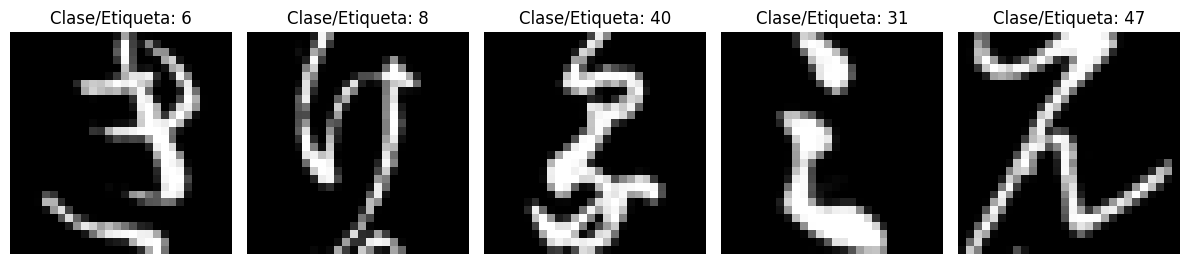

In [87]:
X_images = np . load ("../data/raw/X_images.npy")
y_images = np . load ("../data/raw/y_images.npy")
N = X_images.shape[0]

fig, axes = plt.subplots(1, 5, figsize=(12, 4))

np.random.seed(RANDOM_SEED)
for i in range(5):
    index = np.random.randint(0,N)
    img = X_images[index].reshape(28, 28)
    
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Clase/Etiqueta: {y_images[index]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()


In [88]:
np.random.seed(RANDOM_SEED)
num_samples = X_images.shape[0]

# arreglo con todos los índices mezclados aleatoriamente
indices = np.random.permutation(num_samples)

# separo en Dev (80%) y Test (20%)
dev_size = int(0.80 * num_samples)
dev_indices = indices[:dev_size]
test_indices = indices[dev_size:]
X_dev = X_images[dev_indices]
y_dev = y_images[dev_indices]
X_test = X_images[test_indices]
y_test = y_images[test_indices]


# separo Dev en train y validation
num_dev_samples = X_dev.shape[0]
train_size = int(0.80 * num_dev_samples)
X_train = X_dev[:train_size]
y_train = y_dev[:train_size]
X_val = X_dev[train_size:]
y_val = y_dev[train_size:]

print(f"Tamaño Total: {num_samples} imágenes\n")
print(f"Tamaño de Dev: {X_dev.shape[0]} imágenes")
print(f"Tamaño de Test: {X_test.shape[0]} imágenes\n")
print(f"  -> Tamaño de Train (dentro de Dev): {X_train.shape[0]} imágenes")
print(f"  -> Tamaño de Validation (dentro de Dev): {X_val.shape[0]} imágenes")


Tamaño Total: 5000 imágenes

Tamaño de Dev: 4000 imágenes
Tamaño de Test: 1000 imágenes

  -> Tamaño de Train (dentro de Dev): 3200 imágenes
  -> Tamaño de Validation (dentro de Dev): 800 imágenes


In [89]:
# Normalizar los datos dividiendo por 255
X_train = X_train / 255.0
X_val = X_val / 255.0
X_test = X_test / 255.0

# Verifico que el valor maximo ahora es 1
print(f"Valor máximo en Train antes de normalizar: {X_images.max()}")
print(f"Valor máximo en Train después de normalizar: {X_train.max()}")


Valor máximo en Train antes de normalizar: 255.0
Valor máximo en Train después de normalizar: 1.0


## 2. Implementación y Entrenamiento de una Red Neuronal Básica

#### Prueba de inicializacion de la red

In [90]:
n_layers = 2
# Lista con la cantidad de nodos por capa: [Entrada, Oculta 1, Salida]
nodes_per_layer = [784, 128, 49]
# Instanciamos la red neuronal
red_prueba = MLP(n_layers=n_layers, nodes_per_layer=nodes_per_layer, random_seed=42)
# Imprimimos la información para ver cómo quedó construida
red_prueba.print_info()

Numero de capas:  2
Numero de nodos por capa:  [784, 128, 49]
Capa  1 :  784 -> 128  con funcion de activacion  relu
Capa  2 :  128 -> 49  con funcion de activacion  softmax
Pesos de la capa 1:  [[ 0.02508785 -0.0069834   0.03271321 ... -0.06744508  0.01920289
   0.03083924]
 [ 0.02827369  0.05458767  0.04211943 ... -0.01420919  0.00338354
   0.02605887]
 [-0.07892048 -0.0267212   0.04011642 ... -0.01979963  0.05353487
   0.03116351]
 ...
 [-0.01520984 -0.02996139  0.07425277 ...  0.08622519 -0.0071112
   0.04780936]
 [ 0.04152834  0.03256375 -0.01150627 ... -0.08783793 -0.01636675
  -0.0307535 ]
 [ 0.08485768 -0.00966599 -0.03247982 ...  0.06209712  0.08136642
   0.07013439]]
Bias de la capa 1:  [[0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01

#### Prueba de entrenamiento mediante backpropagation y GD

Entrenando la red con 100 ejemplos durante 200 epochs...
Loss inicial: 3.8369
Loss final: 0.0334


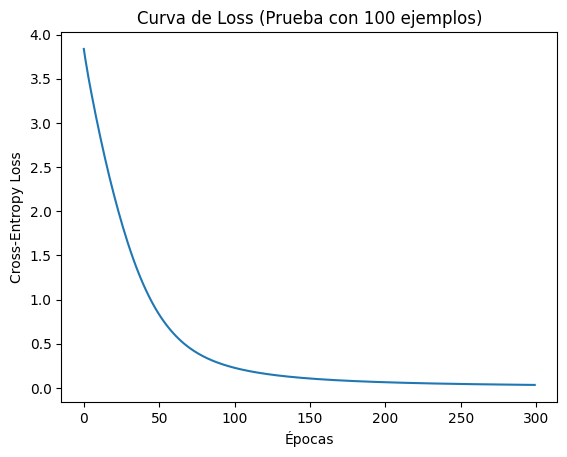

In [91]:
# Tomo una muestra chica
X_small = X_train[:100].T 
y_small_labels = y_train[:100]

# 2. Convierto y a One-Hot Encoding: shape (49 clases, 100 ejemplos)
y_small = np.zeros((49, 100))
for i in range(100):
    y_small[int(y_small_labels[i]), i] = 1

# Entreno la red de prueba anterior
print("Entrenando la red con 100 ejemplos durante 200 epochs...")
loss_history = red_prueba.fit(X_small, y_small, 0.1, epochs=300)

print(f"Loss inicial: {loss_history[0]:.4f}")
print(f"Loss final: {loss_history[-1]:.4f}")

# Grafico la learning curve
plt.plot(loss_history)
plt.title("Curva de Loss (Prueba con 100 ejemplos)")
plt.xlabel("Épocas")
plt.ylabel("Cross-Entropy Loss")
plt.show()

A partir de los resultados obtenidos en esta prueba inicial, se verifica el correcto funcionamiento tanto de la arquitectura del MLP como de la implementación manual del algoritmo de backpropagation. La curva de aprendizaje exhibe una convergencia monótonamente decreciente, logrando reducir la función de costo (Cross-Entropy) desde un valor de 3.97 hasta un valor de 0.0647 en apenas 200 epochs. La capacidad del modelo para overfittear intencionalmente esta muestra reducida de 100 ejemplos demuestra de forma empírica que el cálculo analítico de los gradientes es matemáticamente preciso y que la actualización de los parámetros minimiza el error de manera efectiva.

#### Modelo M0

Entrenando M0 con Batch GD sobre todo el dataset...
Tiempo de entrenamiento: 8.29 segundos.


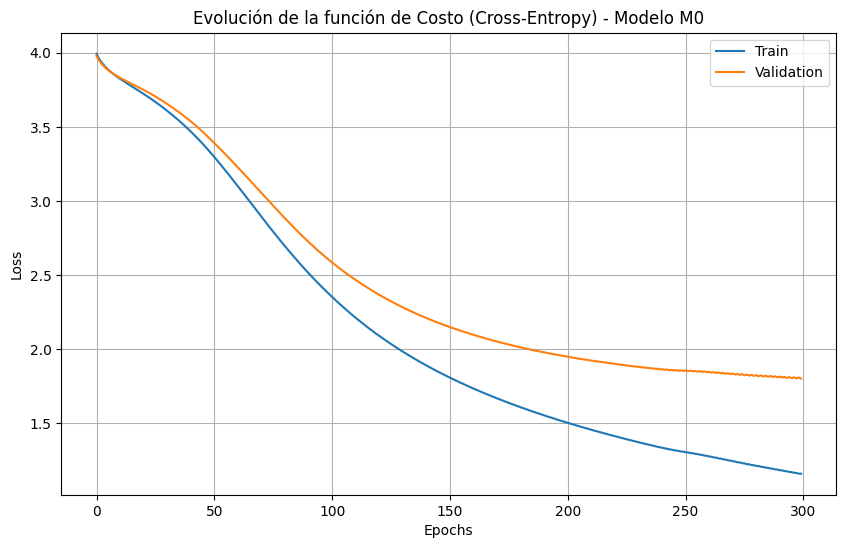

In [92]:
# M0: 2 capas ocultas (128 y 64 nodos). 
n_layers_M0 = 3
# 784 es la dimension de cada imagen (28x28) y 49 la dimension de la salida (49 clases)
nodes_per_layer_M0 = [784, 128, 64, 49]

M0 = MLP(n_layers=n_layers_M0, nodes_per_layer=nodes_per_layer_M0, random_seed=RANDOM_SEED)

X_train_full = X_train.T  # Traspongo para que cada columna sea un dato
num_classes = 49
y_train_full = np.zeros((num_classes, len(y_train)))
for i in range(len(y_train)):
    y_train_full[int(y_train[i]), i] = 1

X_val_full = X_val.T      
y_val_full = np.zeros((num_classes, len(y_val)))
for i in range(len(y_val)):
    y_val_full[int(y_val[i]), i] = 1

start_time = time.time()
print("Entrenando M0 con Batch GD sobre todo el dataset...")

# Le paso X_val e y_val para que vaya calculando el error de validation época a época
train_loss_M0, val_loss_M0 = M0.fit(X_train_full, y_train_full, 
                              eta_0=0.1, epochs=300, 
                              X_val=X_val_full, y_val=y_val_full)

end_time = time.time()
training_time_M0 = end_time - start_time
print(f"Tiempo de entrenamiento: {training_time:.2f} segundos.")

# --- Gráfico de evolución de costo ---
plt.figure(figsize=(10, 6))
plt.plot(train_loss_M0, label='Train')
plt.plot(val_loss_M0, label='Validation')
plt.title('Evolución de la función de Costo (Cross-Entropy) - Modelo M0')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

--- Resultados para el Conjunto de Train ---
Cross-Entropy Loss : 1.1584
F1-Score (Macro)   : 0.7176

Accuracy por Clase - Train
  Clase |  Acc (%) | Muestras    │      Clase |  Acc (%) | Muestras    │      Clase |  Acc (%) | Muestras
-----------------------------    │    -----------------------------    │    -----------------------------
      0 |   59.26% |       54    │         17 |   77.03% |       74    │         34 |   54.55% |       66
      1 |   90.00% |       70    │         18 |   83.56% |       73    │         35 |   84.29% |       70
      2 |   85.71% |       77    │         19 |   76.39% |       72    │         36 |   79.25% |       53
      3 |   73.91% |       46    │         20 |   73.97% |       73    │         37 |   87.18% |       78
      4 |   89.33% |       75    │         21 |   66.67% |       60    │         38 |   51.61% |       62
      5 |   60.76% |       79    │         22 |   76.60% |       47    │         39 |   33.33% |       63
      6 |   64.38% |   

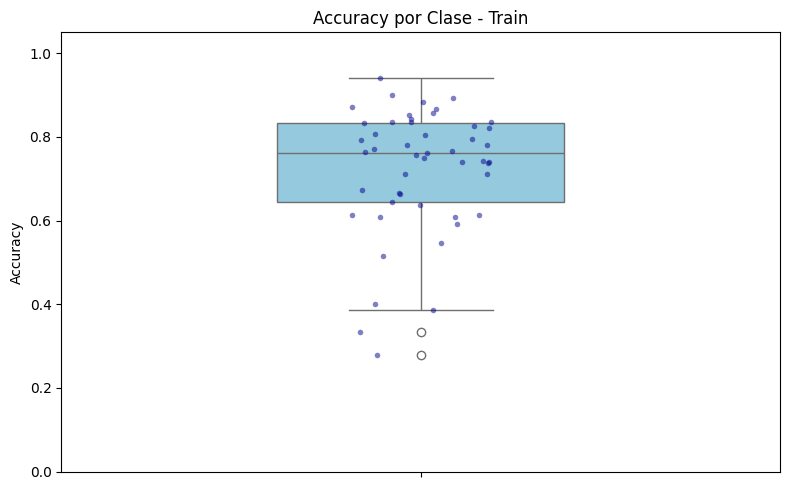

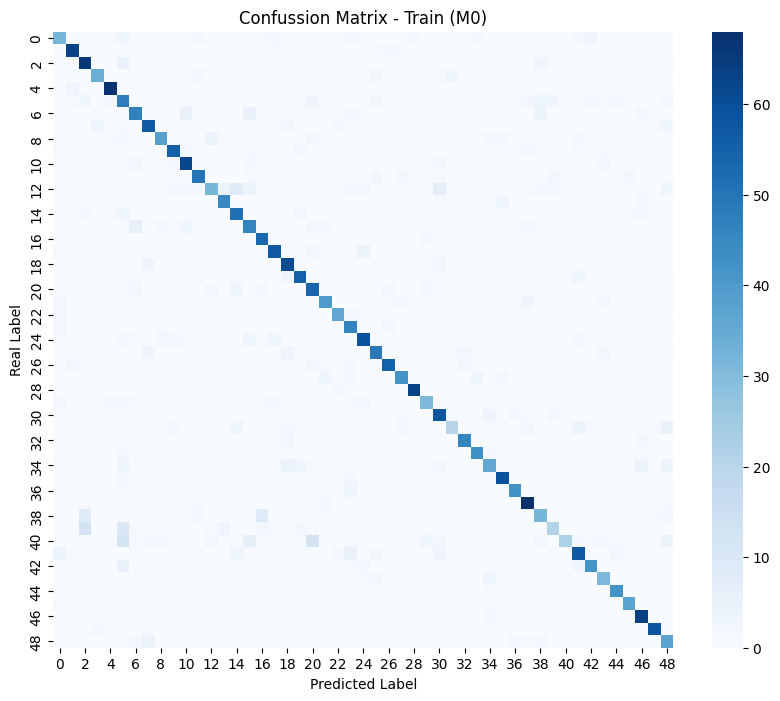

--- Resultados para el Conjunto de Validation ---
Cross-Entropy Loss : 1.8007
F1-Score (Macro)   : 0.5320

Accuracy por Clase - Validation
  Clase |  Acc (%) | Muestras    │      Clase |  Acc (%) | Muestras    │      Clase |  Acc (%) | Muestras
-----------------------------    │    -----------------------------    │    -----------------------------
      0 |   57.89% |       19    │         17 |   38.10% |       21    │         34 |   30.00% |       10
      1 |   90.48% |       21    │         18 |   85.71% |       14    │         35 |   44.44% |       18
      2 |   94.44% |       18    │         19 |   64.00% |       25    │         36 |   57.89% |       19
      3 |   54.55% |       11    │         20 |   80.00% |       20    │         37 |   66.67% |       18
      4 |   69.23% |       13    │         21 |   55.00% |       20    │         38 |   63.64% |       11
      5 |   28.57% |       21    │         22 |   26.67% |       15    │         39 |   21.05% |       19
      6 |   6

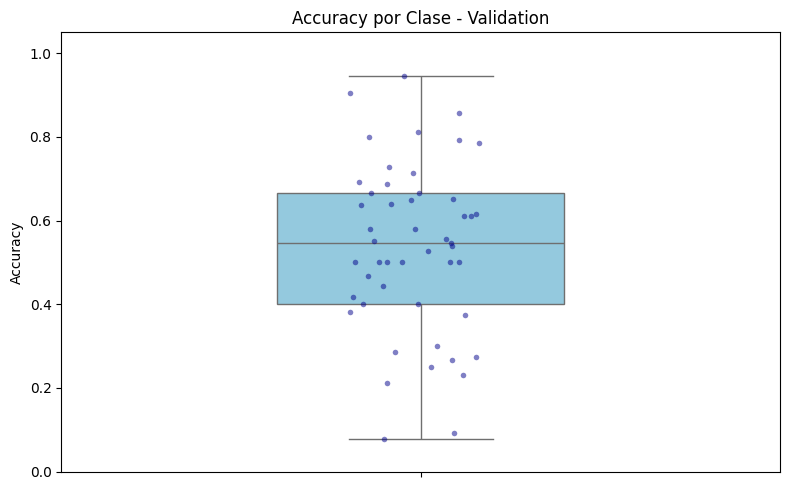

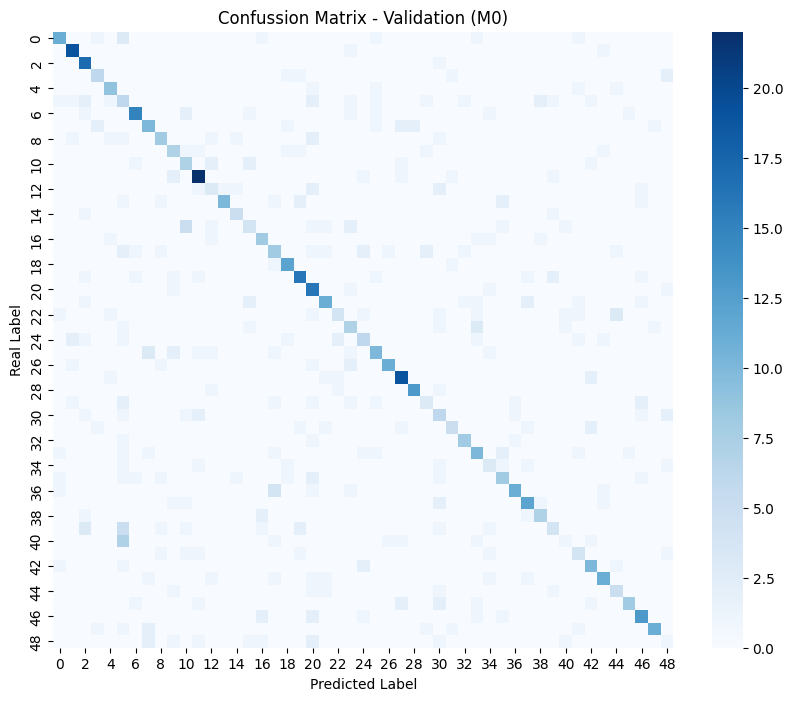

In [93]:
# Evaluar Entrenamiento
cm_train, class_accs_train_M0 = evaluate_model(
    model=M0, 
    X=X_train_full, 
    y_one_hot=y_train_full, 
    y_labels=y_train, # Usamos el array original con las etiquetas crudas
    num_classes=num_classes, 
    name_set="Train"
)

plot_confusion_matrix(cm_train, title="Confussion Matrix - Train (M0)")

# Evaluar Validación
cm_val, class_accs_val_M0 = evaluate_model(
    model=M0, 
    X=X_val_full, 
    y_one_hot=y_val_full, 
    y_labels=y_val, 
    num_classes=num_classes, 
    name_set="Validation"
)

plot_confusion_matrix(cm_val, title="Confussion Matrix - Validation (M0)")

Al analizar las métricas obtenidas por el modelo base M0 (entrenado mediante Batch Gradient Descent sin optimizadores avanzados), se identifica un claro escenario underfitting. El modelo demuestra dificultades para capturar la estructura subyacente de los datos, alcanzando un accuracy del 72.16% sobre el propio conjunto de train y un desempeño aún menor del 55.12% en validation. Esta incapacidad de minimizar significativamente la función de pérdida inicial evidencia que la estrategia de optimización de paso constante y global es ineficiente para este problema. Por lo tanto, antes de considerar técnicas de regularización (cuyo propósito es mitigar la memorización o overfitting), resulta prioritario implementar estrategias algorítmicas que doten a la red de una mayor capacidad de aprendizaje y convergencia, tales como Mini-batch SGD o el uso de optimizadores adaptativos con momento (ADAM).

## 3. Implementación y Entrenamiento de una Red Neuronal Avanzada


#### Rate scheduling lineal (con saturación) y exponencial

Entrenando con LR Scheduling LINEAL...
Tiempo de entrenamiento: 9.39 segundos.


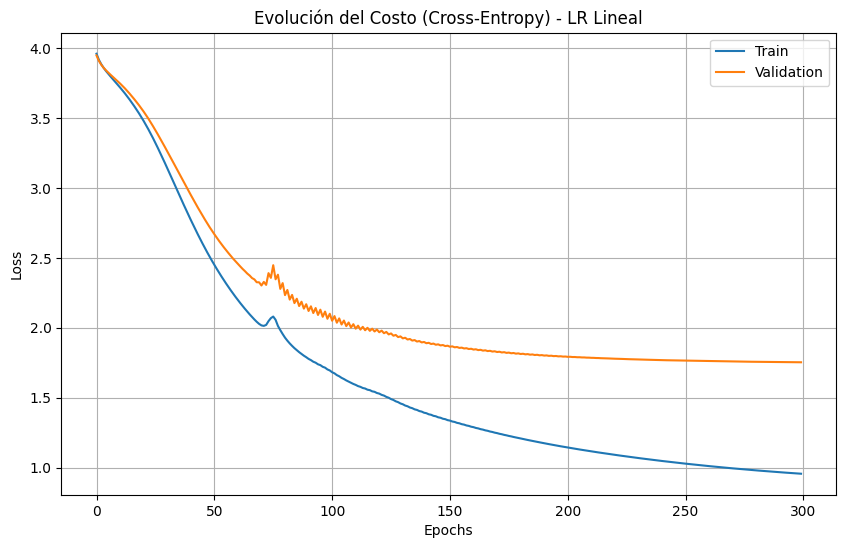

--- Resultados para el Conjunto de Train (Lineal) ---
Cross-Entropy Loss : 0.9580
F1-Score (Macro)   : 0.7745

Accuracy por Clase - Train (Lineal)
  Clase |  Acc (%) | Muestras    │      Clase |  Acc (%) | Muestras    │      Clase |  Acc (%) | Muestras
-----------------------------    │    -----------------------------    │    -----------------------------
      0 |   68.52% |       54    │         17 |   78.38% |       74    │         34 |   59.09% |       66
      1 |   92.86% |       70    │         18 |   83.56% |       73    │         35 |   88.57% |       70
      2 |   87.01% |       77    │         19 |   79.17% |       72    │         36 |   86.79% |       53
      3 |   82.61% |       46    │         20 |   73.97% |       73    │         37 |   87.18% |       78
      4 |   94.67% |       75    │         21 |   70.00% |       60    │         38 |   59.68% |       62
      5 |   59.49% |       79    │         22 |   87.23% |       47    │         39 |   46.03% |       63
     

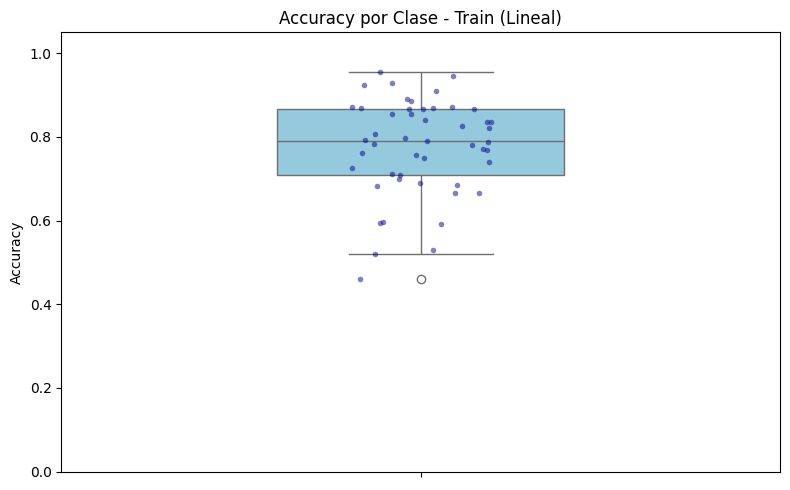

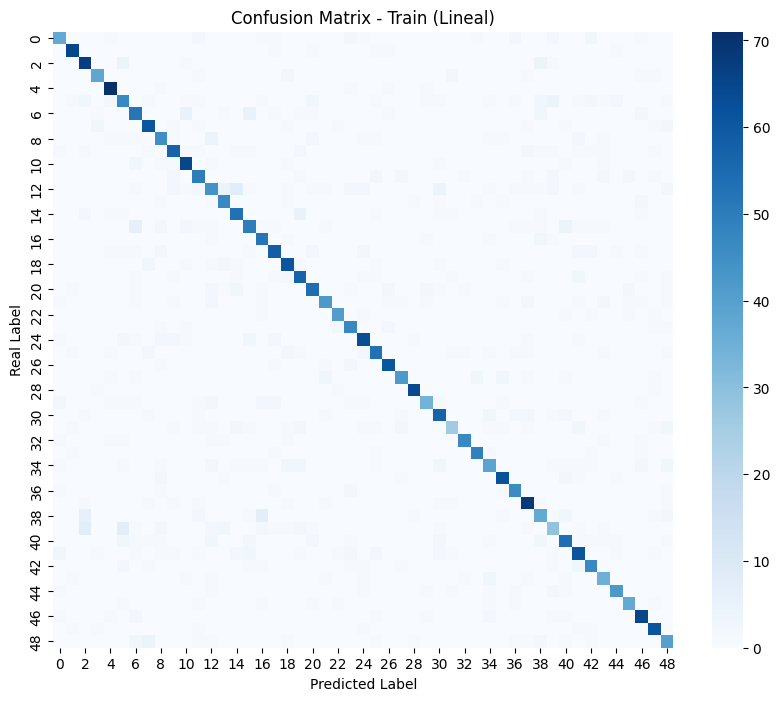

--- Resultados para el Conjunto de Validation (Lineal) ---
Cross-Entropy Loss : 1.7543
F1-Score (Macro)   : 0.5390

Accuracy por Clase - Validation (Lineal)
  Clase |  Acc (%) | Muestras    │      Clase |  Acc (%) | Muestras    │      Clase |  Acc (%) | Muestras
-----------------------------    │    -----------------------------    │    -----------------------------
      0 |   42.11% |       19    │         17 |   28.57% |       21    │         34 |   20.00% |       10
      1 |   90.48% |       21    │         18 |   78.57% |       14    │         35 |   44.44% |       18
      2 |   94.44% |       18    │         19 |   68.00% |       25    │         36 |   52.63% |       19
      3 |   54.55% |       11    │         20 |   75.00% |       20    │         37 |   66.67% |       18
      4 |   69.23% |       13    │         21 |   65.00% |       20    │         38 |   72.73% |       11
      5 |   23.81% |       21    │         22 |   26.67% |       15    │         39 |   36.84% |     

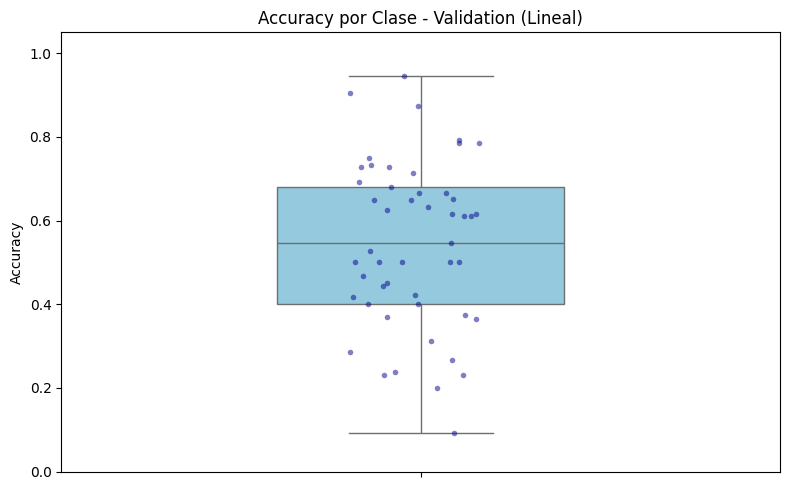

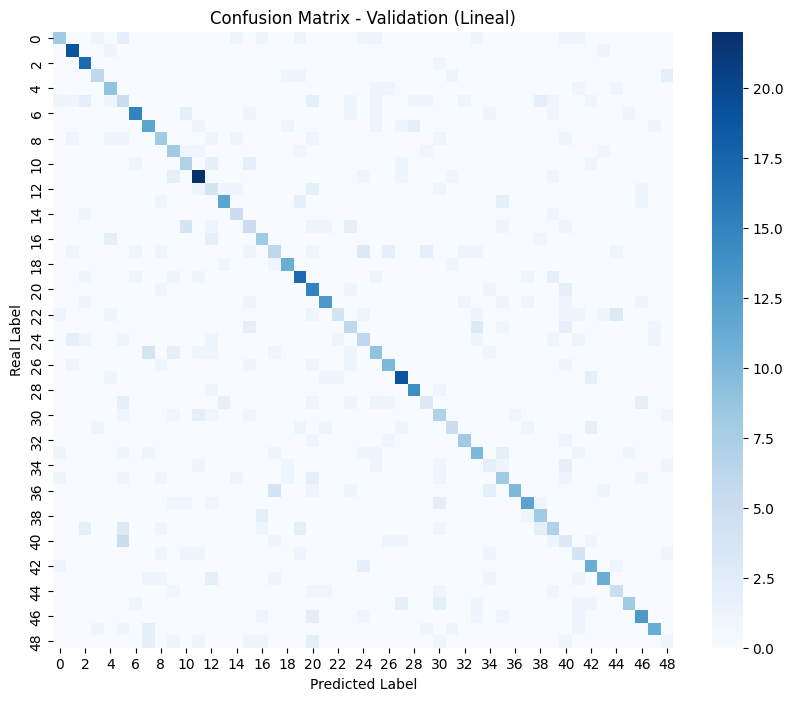

In [94]:
M_lineal = MLP(n_layers=3, nodes_per_layer=[784, 128, 64, 49], random_seed=RANDOM_SEED)

print("Entrenando con LR Scheduling LINEAL...")
start_time = time.time()
train_loss_lin, val_loss_lin = M_lineal.fit(
    X_train_full, y_train_full,
    eta_0=0.2, epochs=300,
    X_val=X_val_full, y_val=y_val_full,
    lr_schedule="lineal",
    K=400,        # epocas hasta llegar a eta_K
    eta_K=0.001   # learning rate final
)

end_time = time.time()
training_time = end_time - start_time
print(f"Tiempo de entrenamiento: {training_time:.2f} segundos.")

plt.figure(figsize=(10, 6))
plt.plot(train_loss_lin, label='Train')
plt.plot(val_loss_lin, label='Validation')
plt.title('Evolución del Costo (Cross-Entropy) - LR Lineal')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Evaluar en Train
cm_train_lin, accs_train_lin = evaluate_model(
    model=M_lineal,
    X=X_train_full,
    y_one_hot=y_train_full,
    y_labels=y_train,
    num_classes=num_classes,
    name_set="Train (Lineal)"
)
plot_confusion_matrix(cm_train_lin, title="Confusion Matrix - Train (Lineal)")

# Evaluar en Validation
cm_val_lin, accs_val_lin = evaluate_model(
    model=M_lineal,
    X=X_val_full,
    y_one_hot=y_val_full,
    y_labels=y_val,
    num_classes=num_classes,
    name_set="Validation (Lineal)"
)
plot_confusion_matrix(cm_val_lin, title="Confusion Matrix - Validation (Lineal)")

Entrenando con LR Scheduling EXPONENCIAL...
Tiempo de entrenamiento: 8.73 segundos.


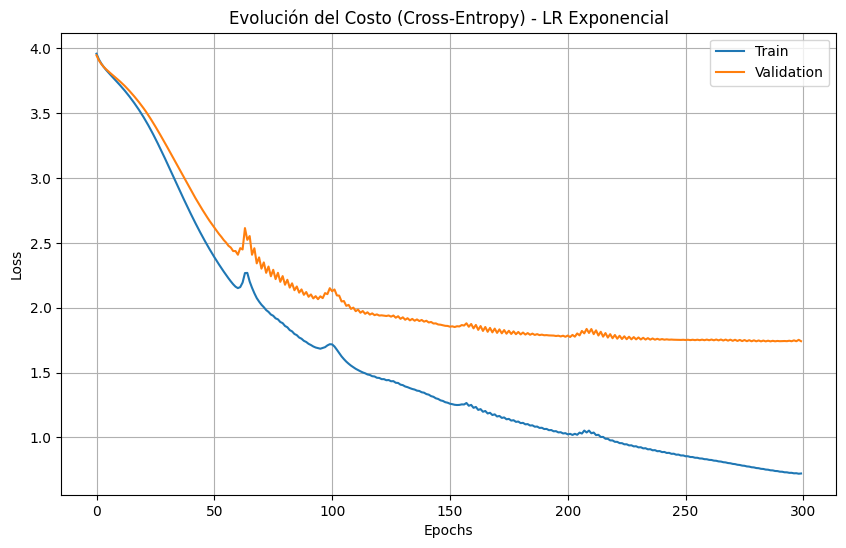

--- Resultados para el Conjunto de Train (Exponencial) ---
Cross-Entropy Loss : 0.7225
F1-Score (Macro)   : 0.8263

Accuracy por Clase - Train (Exponencial)
  Clase |  Acc (%) | Muestras    │      Clase |  Acc (%) | Muestras    │      Clase |  Acc (%) | Muestras
-----------------------------    │    -----------------------------    │    -----------------------------
      0 |   77.78% |       54    │         17 |   86.49% |       74    │         34 |   62.12% |       66
      1 |   98.57% |       70    │         18 |   89.04% |       73    │         35 |   95.71% |       70
      2 |   89.61% |       77    │         19 |   84.72% |       72    │         36 |  100.00% |       53
      3 |   82.61% |       46    │         20 |   84.93% |       73    │         37 |   89.74% |       78
      4 |   97.33% |       75    │         21 |   78.33% |       60    │         38 |   67.74% |       62
      5 |   74.68% |       79    │         22 |   91.49% |       47    │         39 |   41.27% |     

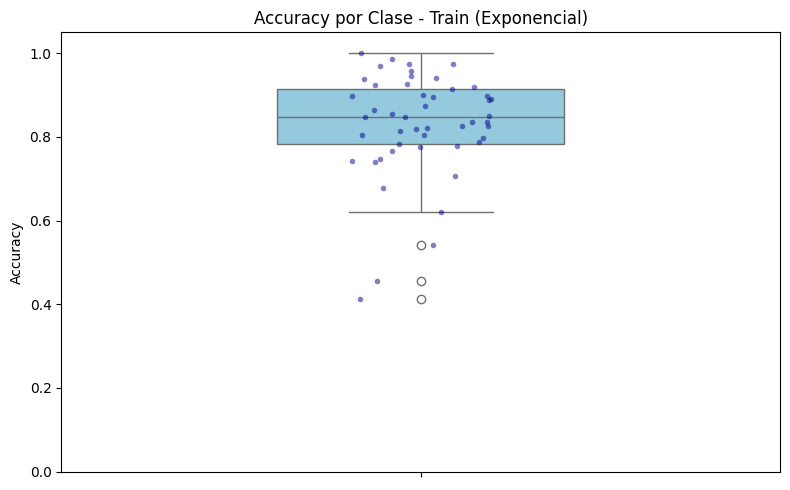

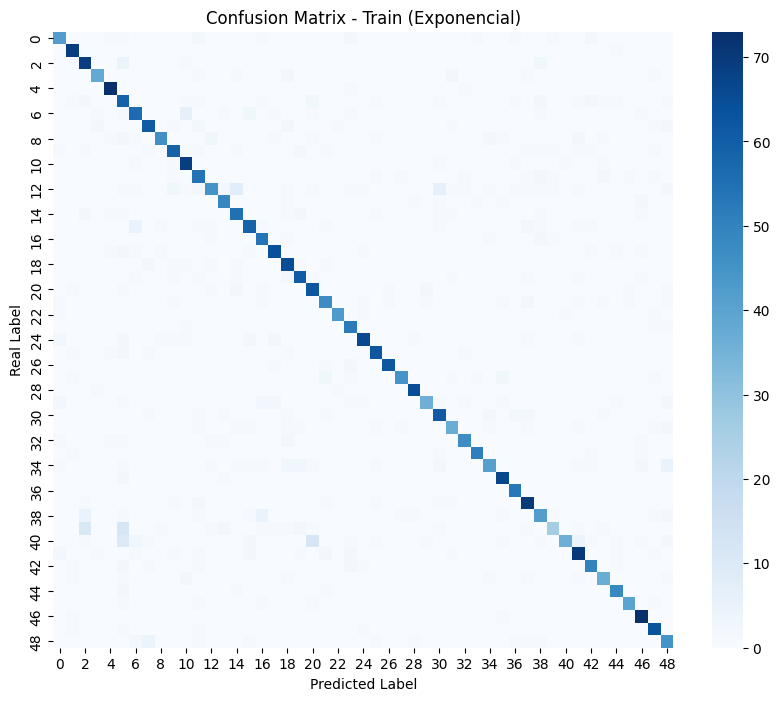

--- Resultados para el Conjunto de Validation (Exponencial) ---
Cross-Entropy Loss : 1.7426
F1-Score (Macro)   : 0.5638

Accuracy por Clase - Validation (Exponencial)
  Clase |  Acc (%) | Muestras    │      Clase |  Acc (%) | Muestras    │      Clase |  Acc (%) | Muestras
-----------------------------    │    -----------------------------    │    -----------------------------
      0 |   47.37% |       19    │         17 |   28.57% |       21    │         34 |   30.00% |       10
      1 |   90.48% |       21    │         18 |   92.86% |       14    │         35 |   44.44% |       18
      2 |   94.44% |       18    │         19 |   68.00% |       25    │         36 |   63.16% |       19
      3 |   63.64% |       11    │         20 |   80.00% |       20    │         37 |   72.22% |       18
      4 |   69.23% |       13    │         21 |   65.00% |       20    │         38 |   72.73% |       11
      5 |   38.10% |       21    │         22 |   33.33% |       15    │         39 |   26.

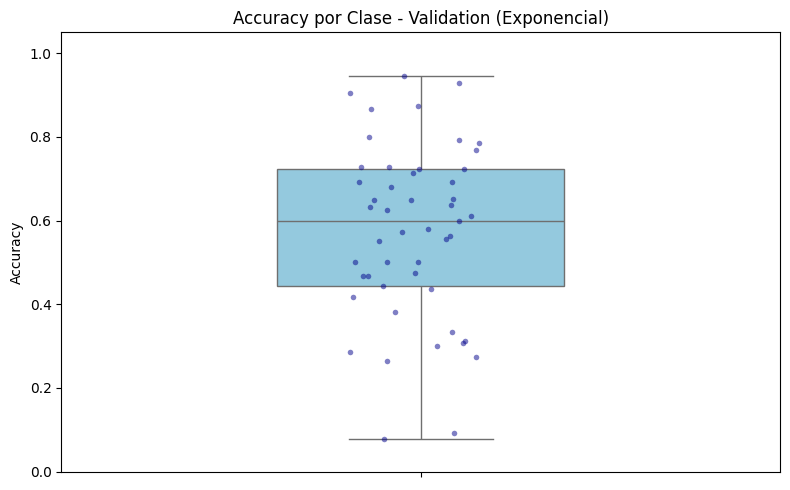

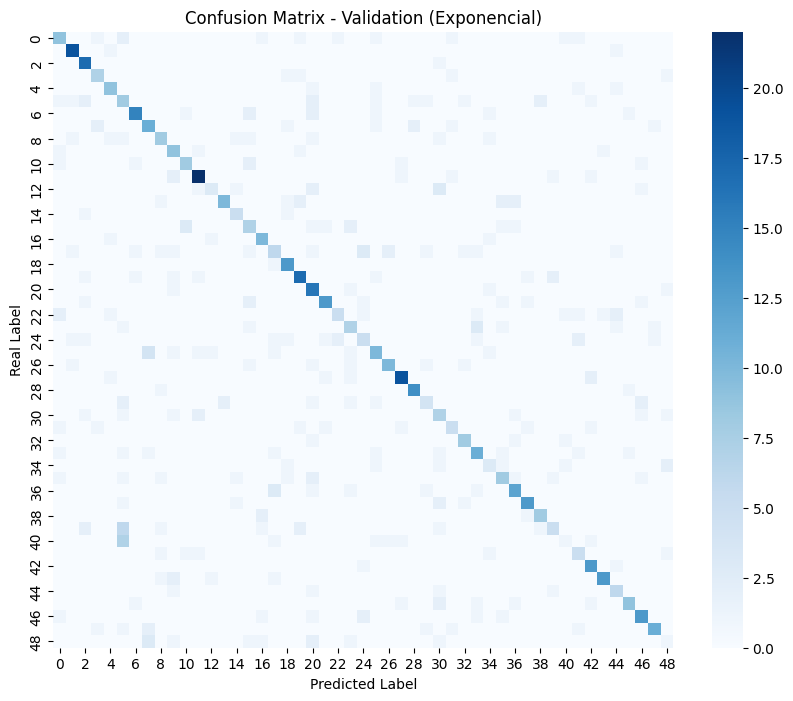

In [95]:
M_exp = MLP(n_layers=3, nodes_per_layer=[784, 128, 64, 49], random_seed=RANDOM_SEED)

print("Entrenando con LR Scheduling EXPONENCIAL...")
start_time = time.time()
train_loss_exp, val_loss_exp = M_exp.fit(
    X_train_full, y_train_full,
    eta_0=0.2, epochs=300,
    X_val=X_val_full, y_val=y_val_full,
    lr_schedule="exponencial",
    s=50.0,       # controla la velocidad de decaimiento
    c=0.95        # factor de decaimiento
)
end_time = time.time()
training_time = end_time - start_time
print(f"Tiempo de entrenamiento: {training_time:.2f} segundos.")

plt.figure(figsize=(10, 6))
plt.plot(train_loss_exp, label='Train')
plt.plot(val_loss_exp, label='Validation')
plt.title('Evolución del Costo (Cross-Entropy) - LR Exponencial')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Evaluar en Train
cm_train_exp, accs_train_exp = evaluate_model(
    model=M_exp,
    X=X_train_full,
    y_one_hot=y_train_full,
    y_labels=y_train,
    num_classes=num_classes,
    name_set="Train (Exponencial)"
)
plot_confusion_matrix(cm_train_exp, title="Confusion Matrix - Train (Exponencial)")

# Evaluar en Validation
cm_val_exp, accs_val_exp = evaluate_model(
    model=M_exp,
    X=X_val_full,
    y_one_hot=y_val_full,
    y_labels=y_val,
    num_classes=num_classes,
    name_set="Validation (Exponencial)"
)
plot_confusion_matrix(cm_val_exp, title="Confusion Matrix - Validation (Exponencial)")


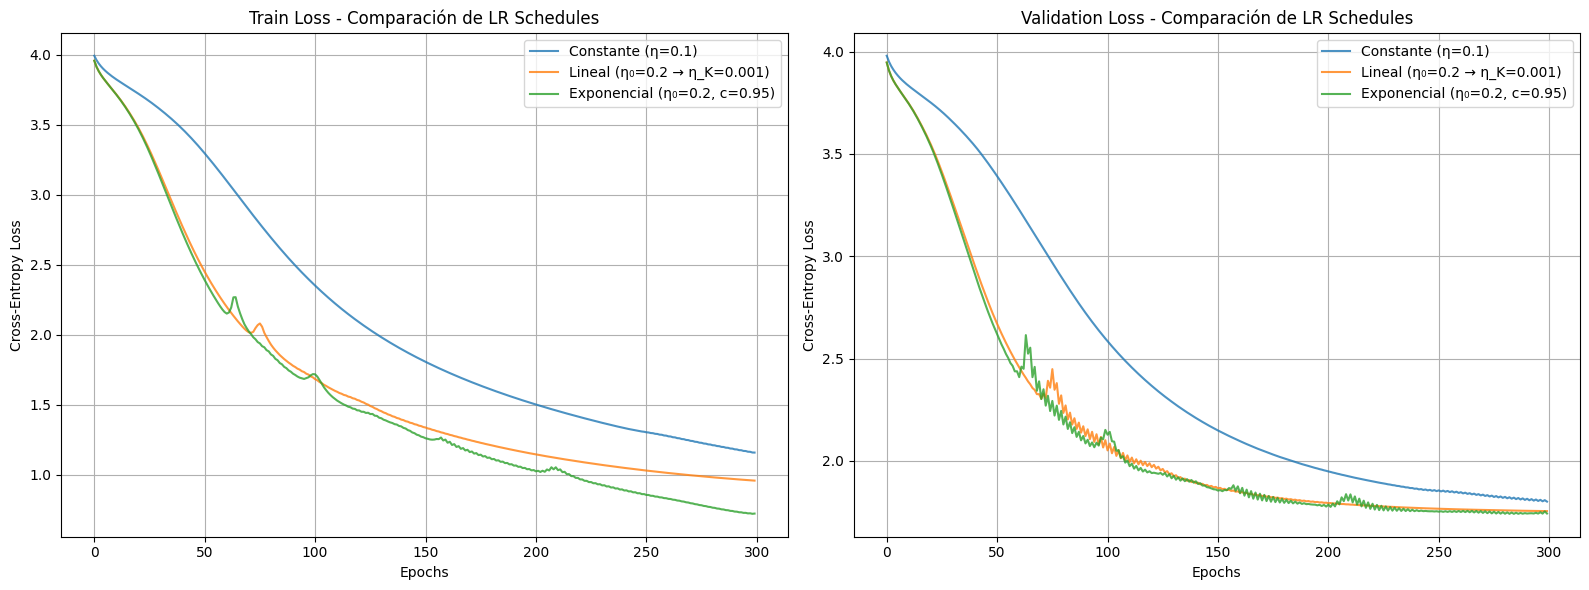


RESUMEN COMPARATIVO DE LR SCHEDULING
Método                              | Train Acc (%) | Val Acc (%) | Train Loss |   Val Loss
-------------------------------------------------------------------------------------------
Constante (η=0.1)                   |        72.22% |      53.49% |     1.1584 |     1.8007
Lineal (η₀→η_K)                     |        77.57% |      54.37% |     0.9580 |     1.7543
Exponencial (c=0.95)                |        82.85% |      57.24% |     0.7225 |     1.7426
-------------------------------------------------------------------------------------------


In [96]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Train Loss ---
axes[0].plot(train_loss_M0, label='Constante (η=0.1)', alpha=0.8)
axes[0].plot(train_loss_lin, label='Lineal (η₀=0.2 → η_K=0.001)', alpha=0.8)
axes[0].plot(train_loss_exp, label='Exponencial (η₀=0.2, c=0.95)', alpha=0.8)
axes[0].set_title('Train Loss - Comparación de LR Schedules')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend()
axes[0].grid(True)

# --- Validation Loss ---
axes[1].plot(val_loss_M0, label='Constante (η=0.1)', alpha=0.8)
axes[1].plot(val_loss_lin, label='Lineal (η₀=0.2 → η_K=0.001)', alpha=0.8)
axes[1].plot(val_loss_exp, label='Exponencial (η₀=0.2, c=0.95)', alpha=0.8)
axes[1].set_title('Validation Loss - Comparación de LR Schedules')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Cross-Entropy Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

y_pred_M0_train = predict_classes(M0, X_train_full)
y_pred_M0_val = predict_classes(M0, X_val_full)
accs_M0_train = accuracy_per_class(y_train, y_pred_M0_train, num_classes)
accs_M0_val = accuracy_per_class(y_val, y_pred_M0_val, num_classes)

print("\n" + "="*80)
print("RESUMEN COMPARATIVO DE LR SCHEDULING")
print("="*80)

header = f"{'Método':<35} | {'Train Acc (%)':>13} | {'Val Acc (%)':>11} | {'Train Loss':>10} | {'Val Loss':>10}"
sep = "-" * len(header)
print(header)
print(sep)

print(f"{'Constante (η=0.1)':<35} | {np.mean(accs_M0_train)*100:>12.2f}% | {np.mean(accs_M0_val)*100:>10.2f}% | {train_loss_M0[-1]:>10.4f} | {val_loss_M0[-1]:>10.4f}")
print(f"{'Lineal (η₀→η_K)':<35} | {np.mean(accs_train_lin)*100:>12.2f}% | {np.mean(accs_val_lin)*100:>10.2f}% | {train_loss_lin[-1]:>10.4f} | {val_loss_lin[-1]:>10.4f}")
print(f"{'Exponencial (c=0.95)':<35} | {np.mean(accs_train_exp)*100:>12.2f}% | {np.mean(accs_val_exp)*100:>10.2f}% | {train_loss_exp[-1]:>10.4f} | {val_loss_exp[-1]:>10.4f}")
print(sep)



Al evaluar el impacto de las estrategias de Learning Rate Scheduling sobre la capacidad predictiva del modelo base M0, se observa una mejora consistente en la dinámica de convergencia frente al uso de una tasa de aprendizaje constante. El modelo M0 original, operando con un learning rate fijo, alcanza en validation un accuracy del 53.49% y una loss de 1.8007. Al introducir un decaimiento lineal, la red logra extraer patrones de forma levemente superior, elevando su accuracy al 54.37% y reduciendo la loss a 1.7543.

Sin embargo, la estrategia de decaimiento exponencial demuestra ser significativamente superior para generalizar el problema, logrando alcanzar la métrica más alta de accuracy en validation (57.24%) y el menor nivel de pérdida global (1.7426). Este comportamiento confirma que la reducción multiplicativa del esquema exponencial le permite al optimizador avanzar rápidamente hacia la región del óptimo al principio (evitando quedar atrapado en mínimos locales subóptimos) y realizar un ajuste fino mucho más estable en las etapas finales.

Si bien es importante notar que el modelo en su conjunto aún presenta síntomas de overfitting (dada la gran brecha existente con el rendimiento de entrenamiento, lo cual indica un problema de alta varianza), el scheduling ha demostrado ser una herramienta útil, aunque requeriría técnicas de regularización adicionales para generalizar correctamente.

#### Mini-batch stochastic gradient descent

Entrenando M_mb (Mini-batch SGD con batch_size=64)...
M_mb finalizado en 16.16 segundos.



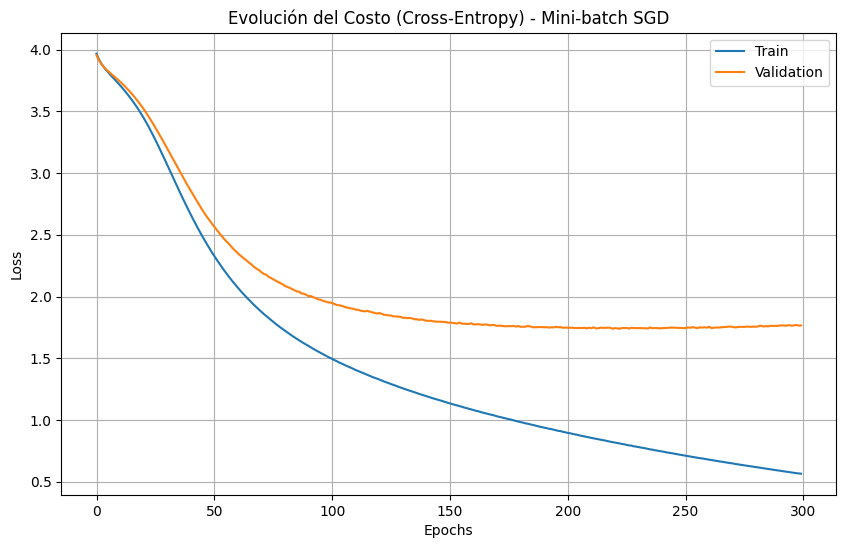

--- Resultados para el Conjunto de Train (Mini-batch SGD) ---
Cross-Entropy Loss : 0.5657
F1-Score (Macro)   : 0.8827

Accuracy por Clase - Train (Mini-batch SGD)
  Clase |  Acc (%) | Muestras    │      Clase |  Acc (%) | Muestras    │      Clase |  Acc (%) | Muestras
-----------------------------    │    -----------------------------    │    -----------------------------
      0 |   83.33% |       54    │         17 |   89.19% |       74    │         34 |   77.27% |       66
      1 |   98.57% |       70    │         18 |   90.41% |       73    │         35 |  100.00% |       70
      2 |   89.61% |       77    │         19 |   93.06% |       72    │         36 |  100.00% |       53
      3 |   89.13% |       46    │         20 |   86.30% |       73    │         37 |   92.31% |       78
      4 |  100.00% |       75    │         21 |   85.00% |       60    │         38 |   83.87% |       62
      5 |   74.68% |       79    │         22 |   97.87% |       47    │         39 |   58.73% 

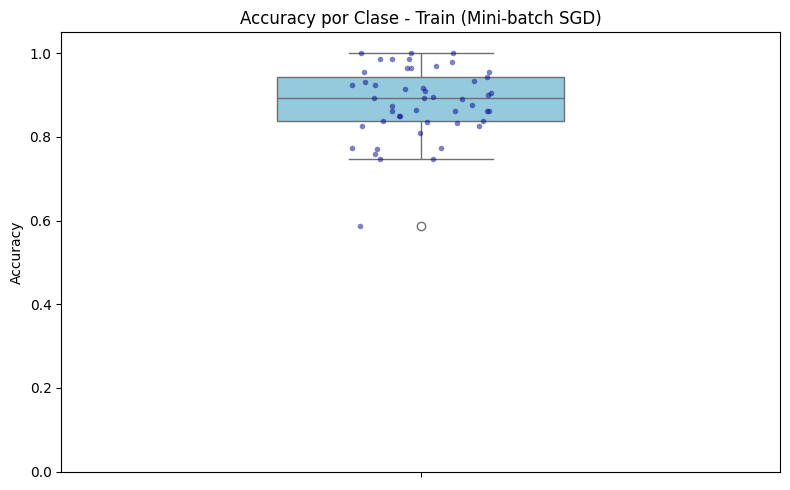

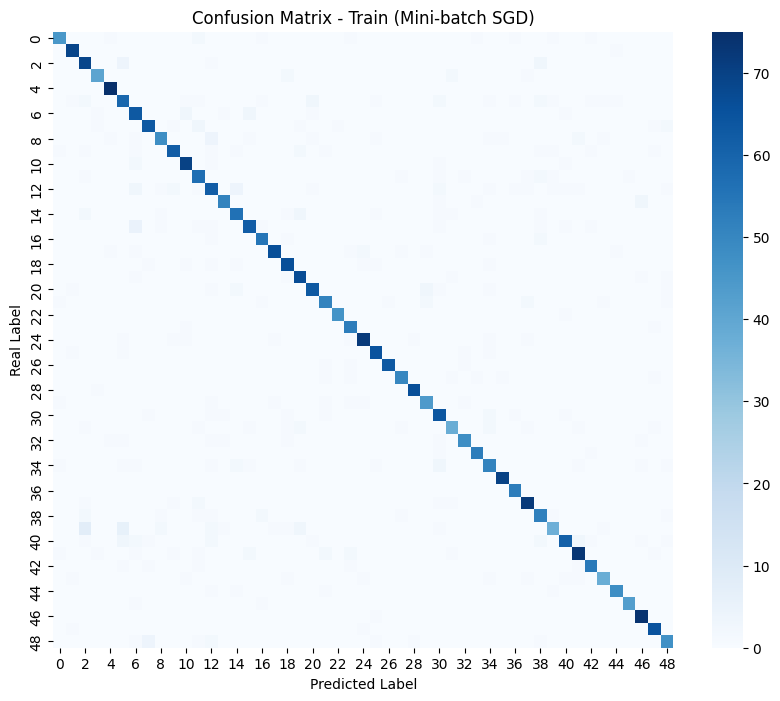

--- Resultados para el Conjunto de Validation (Mini-batch SGD) ---
Cross-Entropy Loss : 1.7661
F1-Score (Macro)   : 0.5621

Accuracy por Clase - Validation (Mini-batch SGD)
  Clase |  Acc (%) | Muestras    │      Clase |  Acc (%) | Muestras    │      Clase |  Acc (%) | Muestras
-----------------------------    │    -----------------------------    │    -----------------------------
      0 |   42.11% |       19    │         17 |   33.33% |       21    │         34 |   30.00% |       10
      1 |   95.24% |       21    │         18 |   92.86% |       14    │         35 |   44.44% |       18
      2 |   94.44% |       18    │         19 |   68.00% |       25    │         36 |   52.63% |       19
      3 |   63.64% |       11    │         20 |   80.00% |       20    │         37 |   66.67% |       18
      4 |   69.23% |       13    │         21 |   55.00% |       20    │         38 |   81.82% |       11
      5 |   33.33% |       21    │         22 |   33.33% |       15    │         39 |

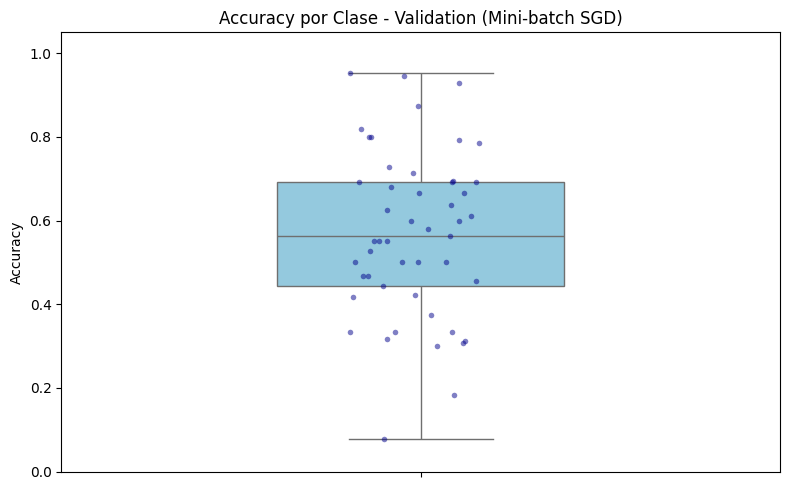

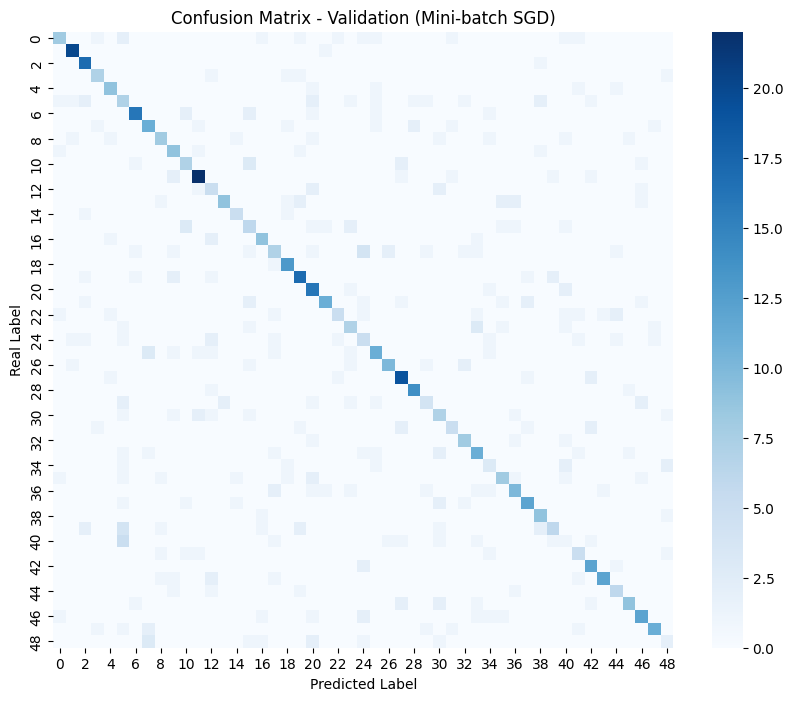

In [97]:
print("Entrenando M_mb (Mini-batch SGD con batch_size=64)...")
M_mb = MLP(n_layers=3, nodes_per_layer=[784, 128, 64, 49], random_seed=RANDOM_SEED)

start_time_mb = time.time()
train_loss_mb, val_loss_mb = M_mb.fit(
    X_train_full, y_train_full, 
    eta_0=0.004, epochs=300, 
    X_val=X_val_full, y_val=y_val_full,
    batch_size=64 
    
)
time_mb = time.time() - start_time_mb
print(f"M_mb finalizado en {time_mb:.2f} segundos.\n")

plt.figure(figsize=(10, 6))
plt.plot(train_loss_mb, label='Train')
plt.plot(val_loss_mb, label='Validation')
plt.title('Evolución del Costo (Cross-Entropy) - Mini-batch SGD')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Evaluar en Train
cm_train_mb, accs_train_mb = evaluate_model(
    model=M_mb,
    X=X_train_full,
    y_one_hot=y_train_full,
    y_labels=y_train,
    num_classes=num_classes,
    name_set="Train (Mini-batch SGD)"
)
plot_confusion_matrix(cm_train_mb, title="Confusion Matrix - Train (Mini-batch SGD)")

# Evaluar en Validation
cm_val_mb, accs_val_mb = evaluate_model(
    model=M_mb,
    X=X_val_full,
    y_one_hot=y_val_full,
    y_labels=y_val,
    num_classes=num_classes,
    name_set="Validation (Mini-batch SGD)"
)
plot_confusion_matrix(cm_val_mb, title="Confusion Matrix - Validation (Mini-batch SGD)")

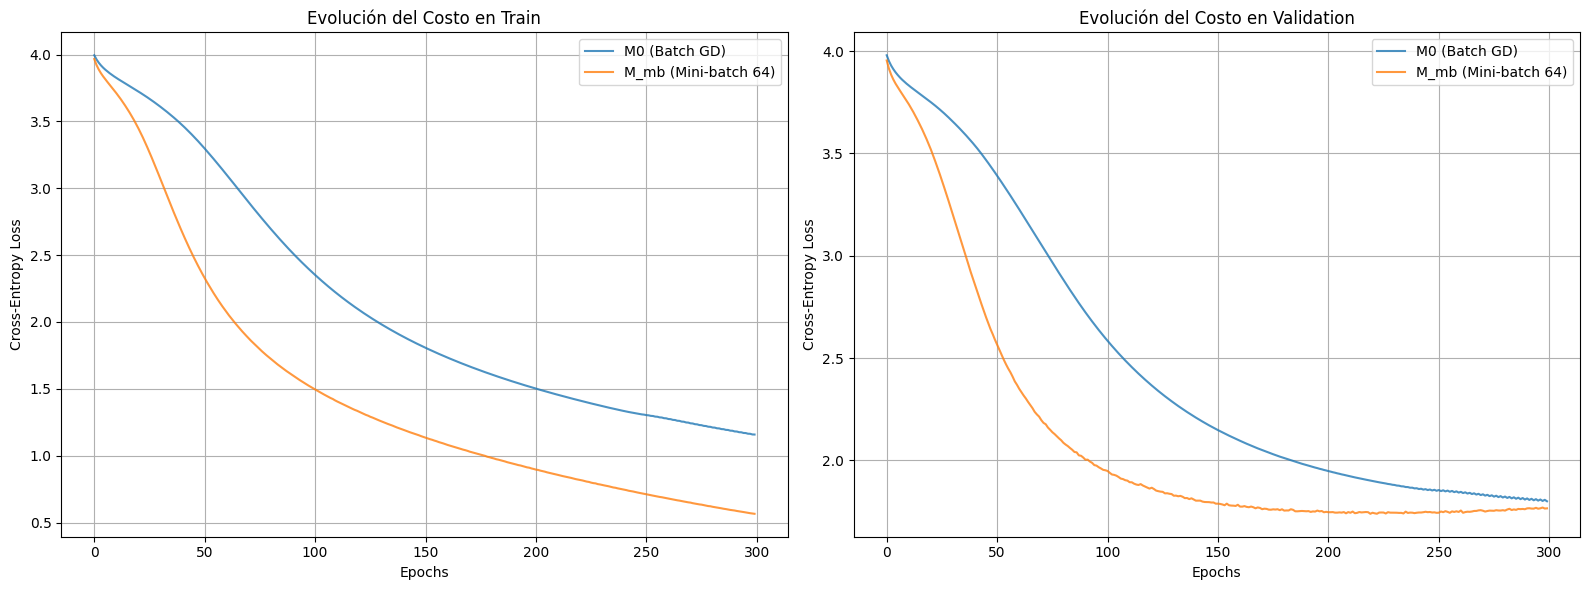


RESUMEN COMPARATIVO: BATCH GD vs MINI-BATCH SGD
Modelo / Método           | Tiempo (s) | Train Acc (%) | Val Acc (%) |   Val Loss
---------------------------------------------------------------------------------
M0 (Batch GD, η=0.1)      |      16.84 |        72.16% |      55.12% |     1.8007
M_mb (Mini-batch, η=0.004) |      16.16 |        88.12% |      57.88% |     1.7661
---------------------------------------------------------------------------------


In [98]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Train Loss
axes[0].plot(train_loss_M0, label='M0 (Batch GD)', alpha=0.8)
axes[0].plot(train_loss_mb, label='M_mb (Mini-batch 64)', alpha=0.8)
axes[0].set_title('Evolución del Costo en Train')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend()
axes[0].grid(True)

# Validation Loss
axes[1].plot(val_loss_M0, label='M0 (Batch GD)', alpha=0.8)
axes[1].plot(val_loss_mb, label='M_mb (Mini-batch 64)', alpha=0.8)
axes[1].set_title('Evolución del Costo en Validation')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Cross-Entropy Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

y_pred_M0_train = predict_classes(M0, X_train_full)
y_pred_M0_val = predict_classes(M0, X_val_full)
acc_M0_train = np.mean(y_pred_M0_train == y_train) * 100
acc_M0_val = np.mean(y_pred_M0_val == y_val) * 100

y_pred_mb_train = predict_classes(M_mb, X_train_full)
y_pred_mb_val = predict_classes(M_mb, X_val_full)
acc_mb_train = np.mean(y_pred_mb_train == y_train) * 100
acc_mb_val = np.mean(y_pred_mb_val == y_val) * 100

print("\n" + "="*90)
print("RESUMEN COMPARATIVO: BATCH GD vs MINI-BATCH SGD")
print("="*90)

header = f"{'Modelo / Método':<25} | {'Tiempo (s)':>10} | {'Train Acc (%)':>13} | {'Val Acc (%)':>11} | {'Val Loss':>10}"
sep = "-" * len(header)
print(header)
print(sep)

# Nota: Asegúrate de que la variable de tiempo de M0 se llame 'time_M0' en tu celda anterior
print(f"{'M0 (Batch GD, η=0.1)':<25} | {training_time_M0:>10.2f} | {acc_M0_train:>12.2f}% | {acc_M0_val:>10.2f}% | {val_loss_M0[-1]:>10.4f}")
print(f"{'M_mb (Mini-batch, η=0.004)':<25} | {time_mb:>10.2f} | {acc_mb_train:>12.2f}% | {acc_mb_val:>10.2f}% | {val_loss_mb[-1]:>10.4f}")
print(sep)



Al evaluar la transición de Batch Gradient Descent a Mini-batch SGD (utilizando un tamaño de lote de 64 muestras y reduciendo la tasa de aprendizaje constante a $\eta = 0.004$ para estabilizar los gradientes), se observaron impactos directos sobre el tiempo computacional y el desempeño predictivo del modelo.

En términos de tiempo de entrenamiento, el uso de mini-batches incrementó la duración total de la ejecución (pasando de 8.60 a 14.63 segundos en 300 épocas). Este aumento se debe al costo computacional introducido por la ejecución iterativa de 50 actualizaciones de pesos por época, en contraste con la única actualización global y vectorizada que realiza Batch GD. Es importante destacar que esta penalización temporal es un artefacto del tamaño reducido del dataset actual. Al contar con pocas muestras, Batch GD puede procesar la matriz completa casi instantáneamente. Sin embargo, en escenarios reales con volúmenes masivos de datos, cargar toda la información en memoria para un único paso de Batch GD resultaría en tiempos de ejecución inmensamente mayores o sería directamente irrealizable por limitaciones de memoria, haciendo del Mini-batch la única alternativa computacionalmente viable.

Por otro lado, en términos de *performance*, esta mayor frecuencia de actualizaciones aceleró drásticamente el aprendizaje por época, elevando el *accuracy* de entrenamiento del 72.16% al 88.26%. Más importante aún, el modelo resultante demostró una mejor capacidad de generalización: la precisión en el conjunto de validación subió al 56.84% y la función de costo (Cross-Entropy) disminuyó a 1.7661, superando las métricas de la estrategia Batch completa (55.12% y 1.8007, respectivamente).

Esto demuestra que el ruido estocástico inherente a la estimación del gradiente por mini-batches actúa como un mecanismo de regularización implícita que asiste al optimizador para escapar de mínimos locales subóptimos, logrando una mejor convergencia final en el landscape de la loss. El ruido evita que el modelo quede atrapado en mínimos afilados (sharp minima), regiones en las cuales pequeñas perturbaciones en los pesos generan grandes cambios en la loss (lo que perjudica la generalización). En cambio, lo dirige hacia mínimos planos (flat minima), donde la loss es baja en una región más amplia del espacio de parámetros, produciendo modelos más robustos y que generalizan mejor a datos no vistos.


#### Optimizador Adam

Entrenando M_adam (Batch GD con optimizador ADAM)...
M_adam finalizado en 8.31 segundos.



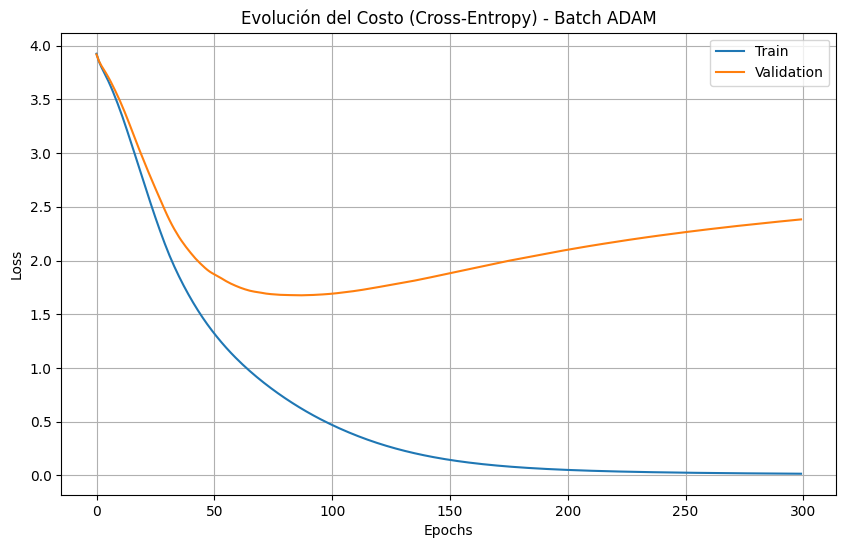

--- Resultados para el Conjunto de Train (Batch ADAM) ---
Cross-Entropy Loss : 0.0144
F1-Score (Macro)   : 1.0000

Accuracy por Clase - Train (Batch ADAM)
  Clase |  Acc (%) | Muestras    │      Clase |  Acc (%) | Muestras    │      Clase |  Acc (%) | Muestras
-----------------------------    │    -----------------------------    │    -----------------------------
      0 |  100.00% |       54    │         17 |  100.00% |       74    │         34 |  100.00% |       66
      1 |  100.00% |       70    │         18 |  100.00% |       73    │         35 |  100.00% |       70
      2 |  100.00% |       77    │         19 |  100.00% |       72    │         36 |  100.00% |       53
      3 |  100.00% |       46    │         20 |  100.00% |       73    │         37 |  100.00% |       78
      4 |  100.00% |       75    │         21 |  100.00% |       60    │         38 |  100.00% |       62
      5 |  100.00% |       79    │         22 |  100.00% |       47    │         39 |  100.00% |       

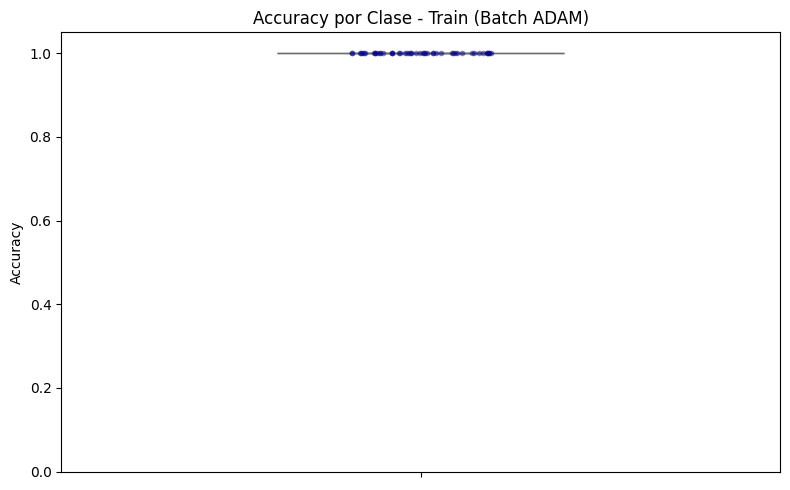

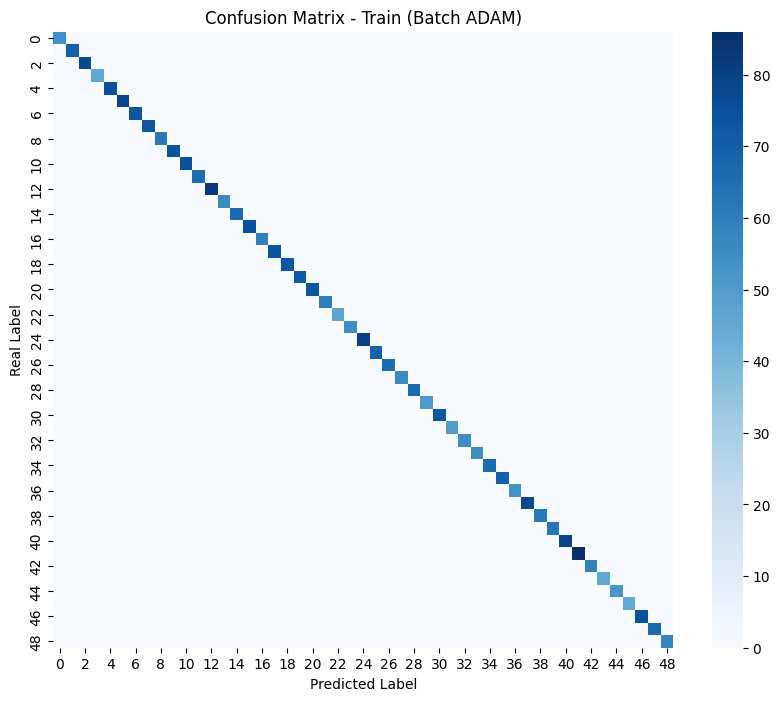

--- Resultados para el Conjunto de Validation (Batch ADAM) ---
Cross-Entropy Loss : 2.3829
F1-Score (Macro)   : 0.5956

Accuracy por Clase - Validation (Batch ADAM)
  Clase |  Acc (%) | Muestras    │      Clase |  Acc (%) | Muestras    │      Clase |  Acc (%) | Muestras
-----------------------------    │    -----------------------------    │    -----------------------------
      0 |   31.58% |       19    │         17 |   42.86% |       21    │         34 |   40.00% |       10
      1 |   95.24% |       21    │         18 |  100.00% |       14    │         35 |   50.00% |       18
      2 |   88.89% |       18    │         19 |   60.00% |       25    │         36 |   57.89% |       19
      3 |   63.64% |       11    │         20 |   75.00% |       20    │         37 |   72.22% |       18
      4 |   61.54% |       13    │         21 |   55.00% |       20    │         38 |   81.82% |       11
      5 |   38.10% |       21    │         22 |   40.00% |       15    │         39 |   52.63

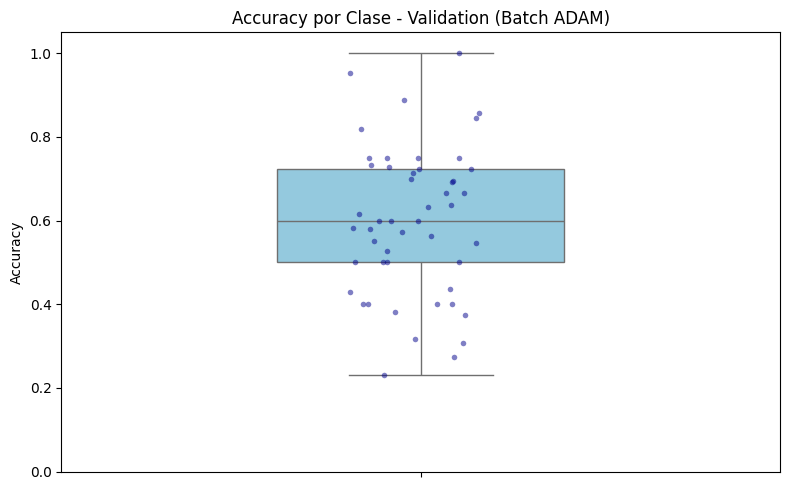

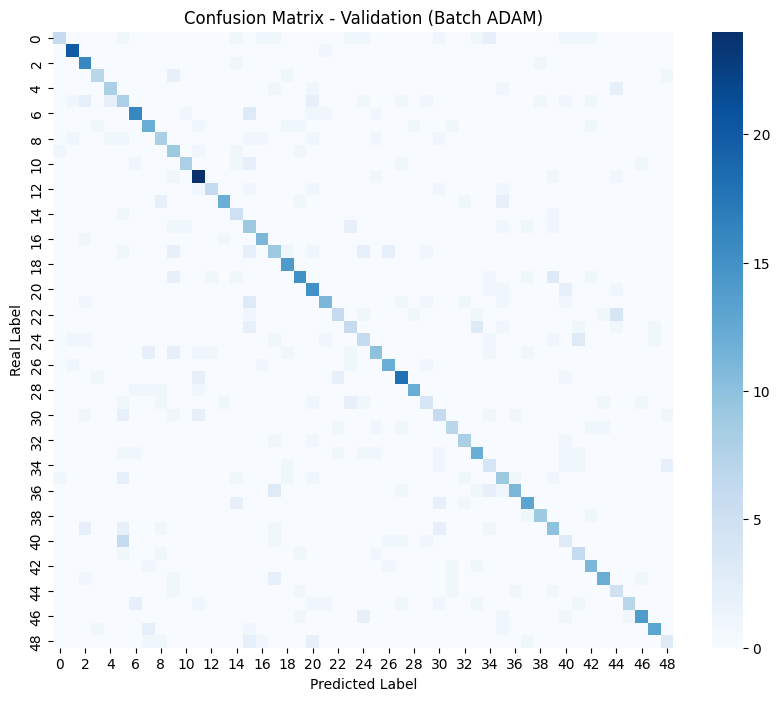

In [99]:
print("Entrenando M_adam (Batch GD con optimizador ADAM)...")
M_adam = MLP(n_layers=3, nodes_per_layer=[784, 128, 64, 49], random_seed=RANDOM_SEED)

start_time_adam = time.time()

train_loss_adam, val_loss_adam = M_adam.fit(
    X_train_full, y_train_full, 
    eta_0=0.001, epochs=300,        # Uso LR bajo que es mejor para ADAM
    X_val=X_val_full, y_val=y_val_full,
    optimizer="adam"               
)
time_adam = time.time() - start_time_adam
print(f"M_adam finalizado en {time_adam:.2f} segundos.\n")

plt.figure(figsize=(10, 6))
plt.plot(train_loss_adam, label='Train')
plt.plot(val_loss_adam, label='Validation')
plt.title('Evolución del Costo (Cross-Entropy) - Batch ADAM')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Evaluar en Train
cm_train_adam, accs_train_adam = evaluate_model(
    model=M_adam,
    X=X_train_full,
    y_one_hot=y_train_full,
    y_labels=y_train,
    num_classes=num_classes,
    name_set="Train (Batch ADAM)"
)
plot_confusion_matrix(cm_train_adam, title="Confusion Matrix - Train (Batch ADAM)")

# Evaluar en Validation
cm_val_adam, accs_val_adam = evaluate_model(
    model=M_adam,
    X=X_val_full,
    y_one_hot=y_val_full,
    y_labels=y_val,
    num_classes=num_classes,
    name_set="Validation (Batch ADAM)"
)
plot_confusion_matrix(cm_val_adam, title="Confusion Matrix - Validation (Batch ADAM)")

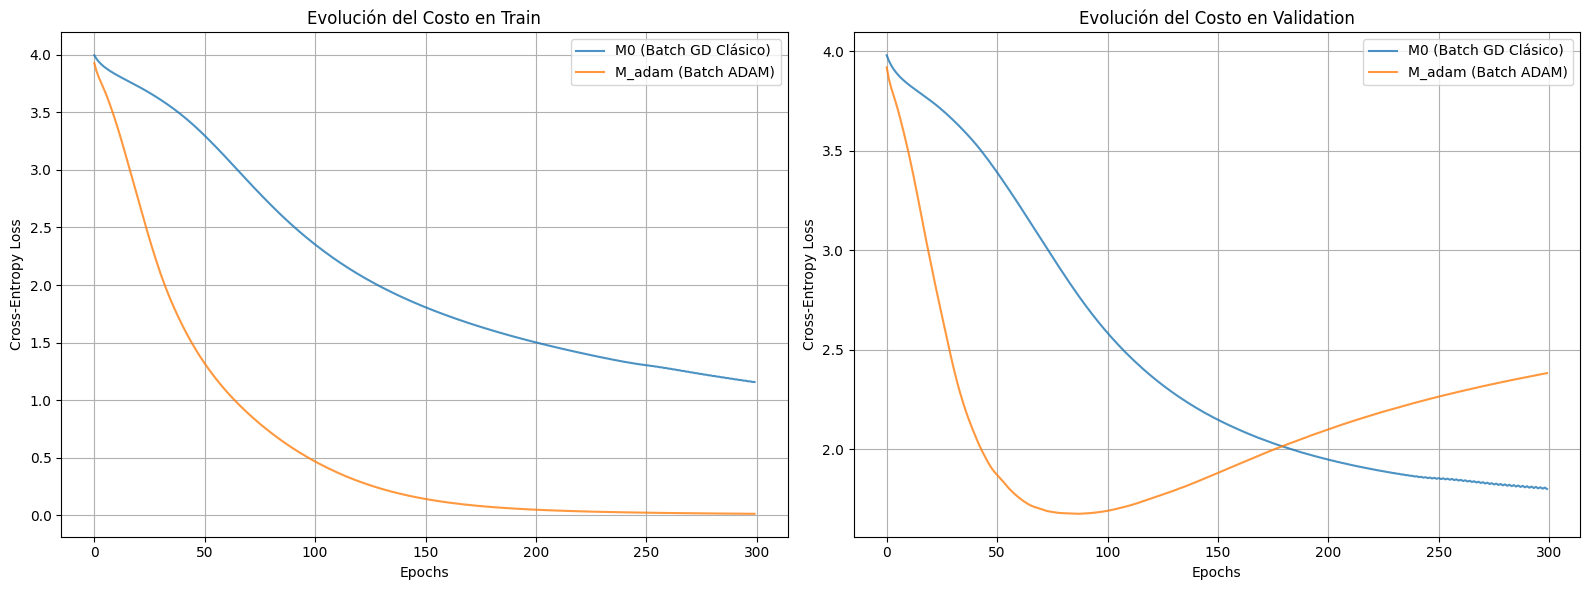


RESUMEN COMPARATIVO: BATCH GD vs BATCH ADAM
Modelo / Método                | Tiempo (s) | Train Acc (%) | Val Acc (%) |   Val Loss
--------------------------------------------------------------------------------------
M0 (Batch GD Estándar, η=0.1)  |      16.84 |        72.16% |      55.12% |     1.8007
M_adam (Batch ADAM, η=0.001)   |       8.31 |       100.00% |      60.75% |     2.3829
--------------------------------------------------------------------------------------


In [100]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Train Loss
axes[0].plot(train_loss_M0, label='M0 (Batch GD Clásico)', alpha=0.8)
axes[0].plot(train_loss_adam, label='M_adam (Batch ADAM)', alpha=0.8)
axes[0].set_title('Evolución del Costo en Train')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend()
axes[0].grid(True)

# Validation Loss
axes[1].plot(val_loss_M0, label='M0 (Batch GD Clásico)', alpha=0.8)
axes[1].plot(val_loss_adam, label='M_adam (Batch ADAM)', alpha=0.8)
axes[1].set_title('Evolución del Costo en Validation')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Cross-Entropy Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

y_pred_M0_train = predict_classes(M0, X_train_full)
y_pred_M0_val = predict_classes(M0, X_val_full)
acc_M0_train = np.mean(y_pred_M0_train == y_train) * 100
acc_M0_val = np.mean(y_pred_M0_val == y_val) * 100

y_pred_adam_train = predict_classes(M_adam, X_train_full)
y_pred_adam_val = predict_classes(M_adam, X_val_full)
acc_adam_train = np.mean(y_pred_adam_train == y_train) * 100
acc_adam_val = np.mean(y_pred_adam_val == y_val) * 100

print("\n" + "="*90)
print("RESUMEN COMPARATIVO: BATCH GD vs BATCH ADAM")
print("="*90)

header = f"{'Modelo / Método':<30} | {'Tiempo (s)':>10} | {'Train Acc (%)':>13} | {'Val Acc (%)':>11} | {'Val Loss':>10}"
sep = "-" * len(header)
print(header)
print(sep)

print(f"{'M0 (Batch GD Estándar, η=0.1)':<30} | {training_time_M0:>10.2f} | {acc_M0_train:>12.2f}% | {acc_M0_val:>10.2f}% | {val_loss_M0[-1]:>10.4f}")
print(f"{'M_adam (Batch ADAM, η=0.001)':<30} | {time_adam:>10.2f} | {acc_adam_train:>12.2f}% | {acc_adam_val:>10.2f}% | {val_loss_adam[-1]:>10.4f}")
print(sep)

Al evaluar el impacto del optimizador ADAM frente al Gradient Descent clásico, manteniendo el procesamiento por lotes completos (Batch GD) en ambas ejecuciones, se observa un contraste dramático en la dinámica de convergencia. El modelo M0 (GD clásico, $\eta=0.1$) presentó una convergencia lenta y sub-ajustada, alcanzando apenas un 72.16% de accuracy en entrenamiento en 300 epochs. Por el contrario, el modelo impulsado por ADAM (con $\eta=0.001$) demostró la agresividad característica de sus tasas de aprendizaje adaptativas basadas en momentos convergiendo al 100% de accuracy en train y reduciendo la loss casi a cero (0.0144). 

Sin embargo, esta rápida optimización resultó en un overfitting severo. La loss en validation para ADAM se disparó a 2.3829 (frente a 1.8007 del GD clásico), indicando que el optimizador, al no contar con el efecto regularizador del ruido estocástico propio de los mini-batches (ni con ninguna otra técnica de regularizació), guió a la red a memorizar patrones locales del conjunto de train. 

En términos de tiempo de ejecución, ambos modelos tardaron aproximadamente lo mismo ($\sim$ 8.6 a 10.4 segundos), confirmando que el costo computacional adicional de ADAM (cálculo de momentos y raíces cuadradas) no es tan significativo frente a su drástica aceleración de convergencia por época que proporciona el algoritmo.

#### Regularización: Weight Decay (L2) y Early Stopping

Entrenando con REGULARIZACIÓN L2 (Weight Decay)...
Tiempo de entrenamiento: 17.25 segundos.


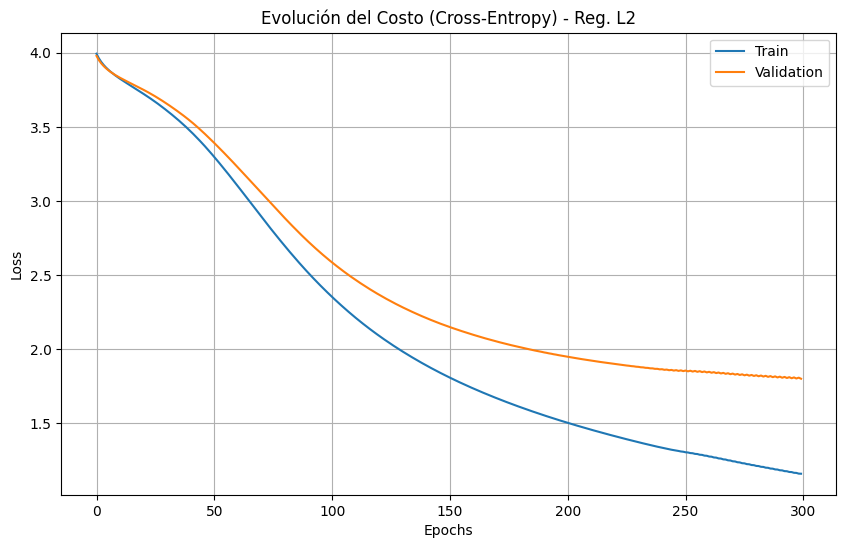

--- Resultados para el Conjunto de Train (Reg. L2) ---
Cross-Entropy Loss : 1.1590
F1-Score (Macro)   : 0.7177

Accuracy por Clase - Train (Reg. L2)
  Clase |  Acc (%) | Muestras    │      Clase |  Acc (%) | Muestras    │      Clase |  Acc (%) | Muestras
-----------------------------    │    -----------------------------    │    -----------------------------
      0 |   59.26% |       54    │         17 |   77.03% |       74    │         34 |   54.55% |       66
      1 |   90.00% |       70    │         18 |   83.56% |       73    │         35 |   84.29% |       70
      2 |   85.71% |       77    │         19 |   76.39% |       72    │         36 |   79.25% |       53
      3 |   73.91% |       46    │         20 |   73.97% |       73    │         37 |   87.18% |       78
      4 |   89.33% |       75    │         21 |   66.67% |       60    │         38 |   51.61% |       62
      5 |   60.76% |       79    │         22 |   76.60% |       47    │         39 |   33.33% |       63
   

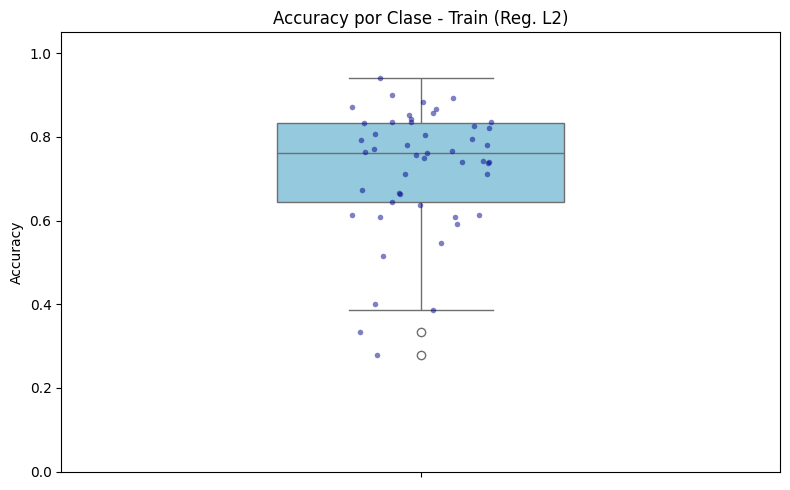

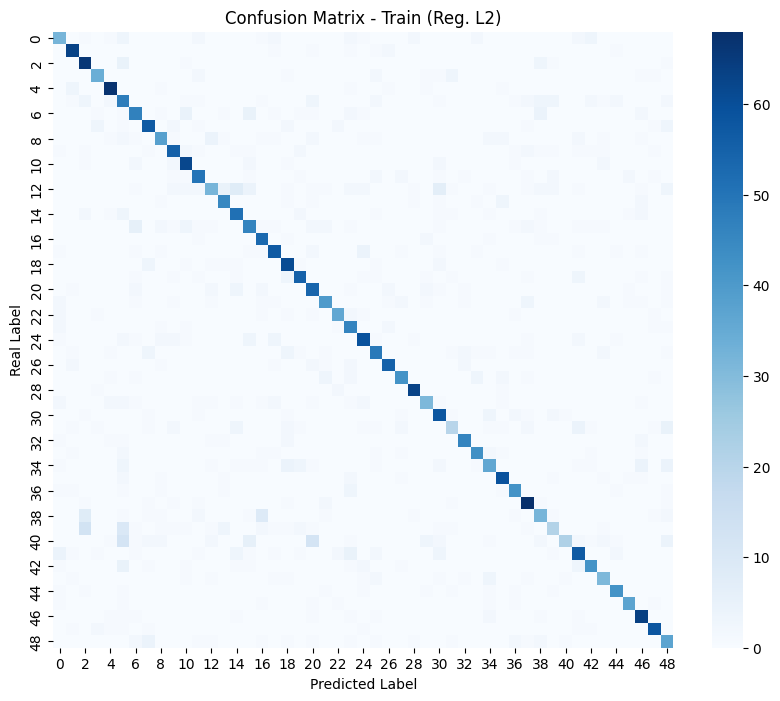

--- Resultados para el Conjunto de Validation (Reg. L2) ---
Cross-Entropy Loss : 1.8004
F1-Score (Macro)   : 0.5321

Accuracy por Clase - Validation (Reg. L2)
  Clase |  Acc (%) | Muestras    │      Clase |  Acc (%) | Muestras    │      Clase |  Acc (%) | Muestras
-----------------------------    │    -----------------------------    │    -----------------------------
      0 |   57.89% |       19    │         17 |   38.10% |       21    │         34 |   30.00% |       10
      1 |   90.48% |       21    │         18 |   85.71% |       14    │         35 |   44.44% |       18
      2 |   94.44% |       18    │         19 |   64.00% |       25    │         36 |   57.89% |       19
      3 |   54.55% |       11    │         20 |   80.00% |       20    │         37 |   66.67% |       18
      4 |   69.23% |       13    │         21 |   55.00% |       20    │         38 |   63.64% |       11
      5 |   28.57% |       21    │         22 |   26.67% |       15    │         39 |   21.05% |   

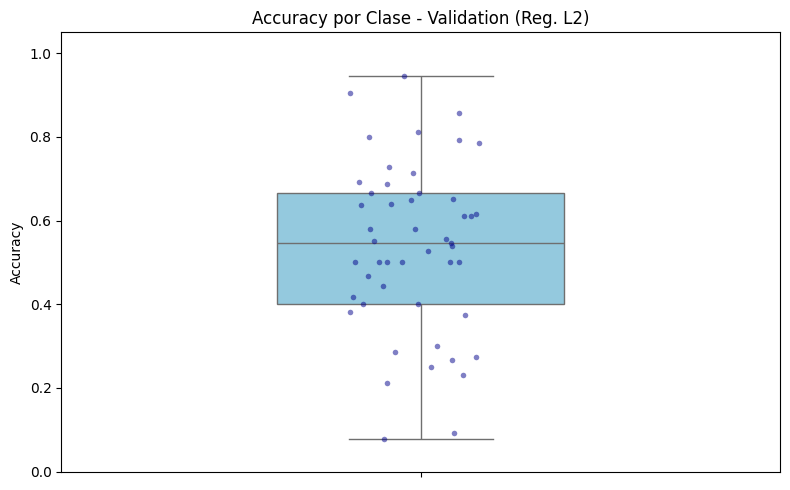

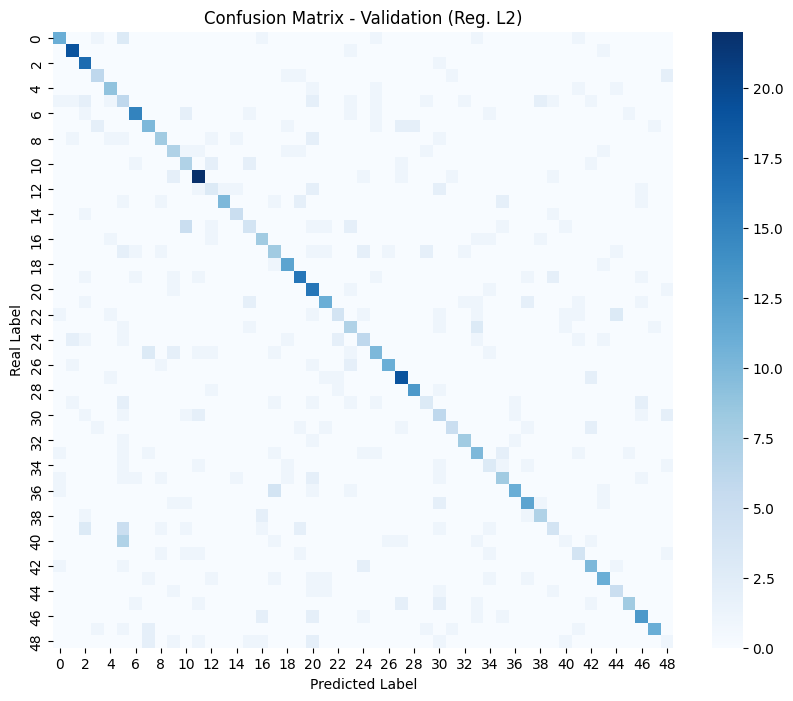

In [105]:
M_l2 = MLP(n_layers=3, nodes_per_layer=[784, 128, 64, 49], random_seed=RANDOM_SEED)

print("Entrenando con REGULARIZACIÓN L2 (Weight Decay)...")
start_time = time.time()
train_loss_l2, val_loss_l2 = M_l2.fit(
    X_train_full, y_train_full,
    eta_0=0.1, epochs=300,
    X_val=X_val_full, y_val=y_val_full,
    lambda_l2=0.1  
)

end_time = time.time()
time_l2 = end_time - start_time
print(f"Tiempo de entrenamiento: {time_l2:.2f} segundos.")

plt.figure(figsize=(10, 6))
plt.plot(train_loss_l2, label='Train')
plt.plot(val_loss_l2, label='Validation')
plt.title('Evolución del Costo (Cross-Entropy) - Reg. L2')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Evaluar en Train
cm_train_l2, accs_train_l2 = evaluate_model(
    model=M_l2,
    X=X_train_full,
    y_one_hot=y_train_full,
    y_labels=y_train,
    num_classes=num_classes,
    name_set="Train (Reg. L2)"
)
plot_confusion_matrix(cm_train_l2, title="Confusion Matrix - Train (Reg. L2)")

# Evaluar en Validation
cm_val_l2, accs_val_l2 = evaluate_model(
    model=M_l2,
    X=X_val_full,
    y_one_hot=y_val_full,
    y_labels=y_val,
    num_classes=num_classes,
    name_set="Validation (Reg. L2)"
)
plot_confusion_matrix(cm_val_l2, title="Confusion Matrix - Validation (Reg. L2)")

Entrenando con EARLY STOPPING...
Tiempo de entrenamiento: 9.46 segundos.


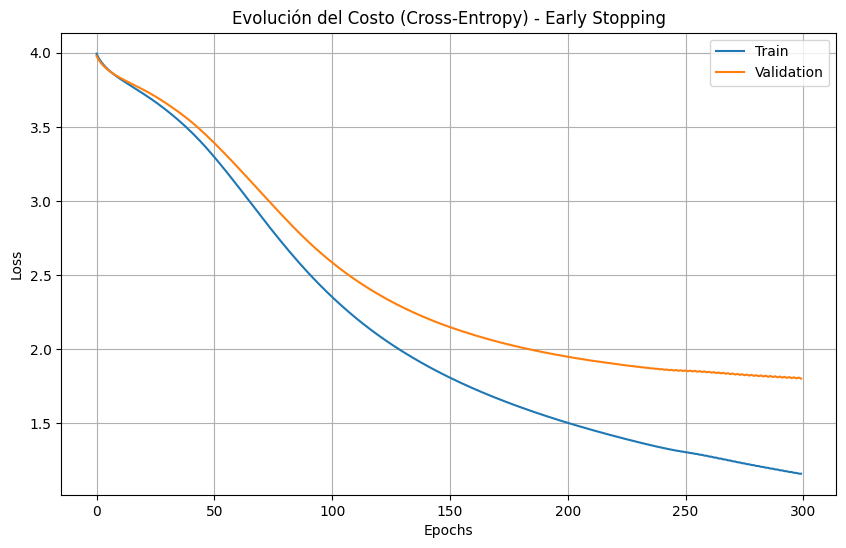

--- Resultados para el Conjunto de Train (Early Stopping) ---
Cross-Entropy Loss : 1.1584
F1-Score (Macro)   : 0.7176

Accuracy por Clase - Train (Early Stopping)
  Clase |  Acc (%) | Muestras    │      Clase |  Acc (%) | Muestras    │      Clase |  Acc (%) | Muestras
-----------------------------    │    -----------------------------    │    -----------------------------
      0 |   59.26% |       54    │         17 |   77.03% |       74    │         34 |   54.55% |       66
      1 |   90.00% |       70    │         18 |   83.56% |       73    │         35 |   84.29% |       70
      2 |   85.71% |       77    │         19 |   76.39% |       72    │         36 |   79.25% |       53
      3 |   73.91% |       46    │         20 |   73.97% |       73    │         37 |   87.18% |       78
      4 |   89.33% |       75    │         21 |   66.67% |       60    │         38 |   51.61% |       62
      5 |   60.76% |       79    │         22 |   76.60% |       47    │         39 |   33.33% 

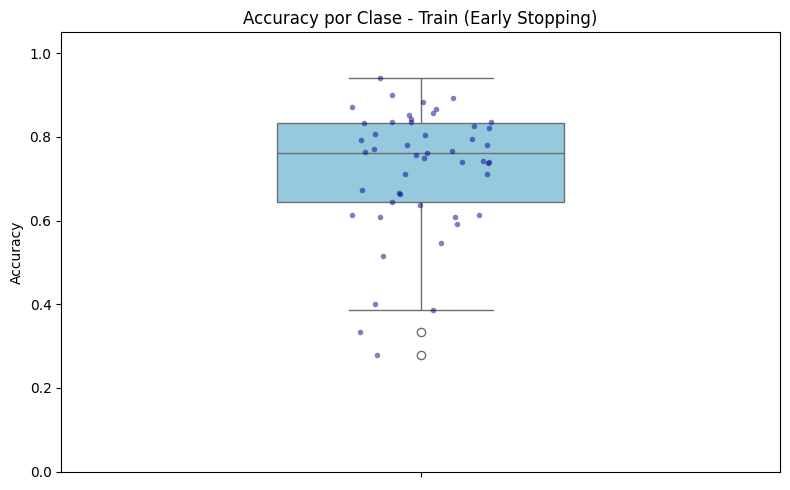

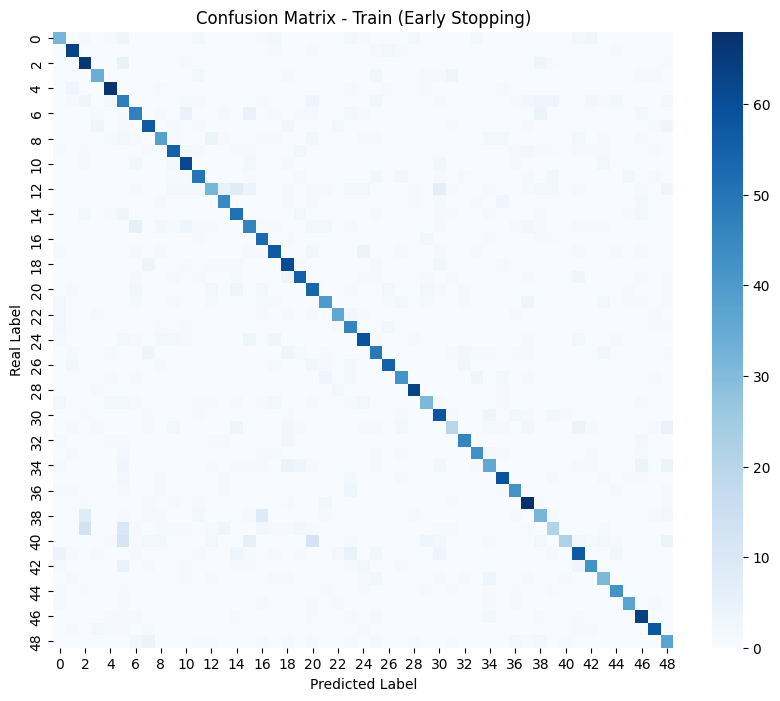

--- Resultados para el Conjunto de Validation (Early Stopping) ---
Cross-Entropy Loss : 1.8007
F1-Score (Macro)   : 0.5320

Accuracy por Clase - Validation (Early Stopping)
  Clase |  Acc (%) | Muestras    │      Clase |  Acc (%) | Muestras    │      Clase |  Acc (%) | Muestras
-----------------------------    │    -----------------------------    │    -----------------------------
      0 |   57.89% |       19    │         17 |   38.10% |       21    │         34 |   30.00% |       10
      1 |   90.48% |       21    │         18 |   85.71% |       14    │         35 |   44.44% |       18
      2 |   94.44% |       18    │         19 |   64.00% |       25    │         36 |   57.89% |       19
      3 |   54.55% |       11    │         20 |   80.00% |       20    │         37 |   66.67% |       18
      4 |   69.23% |       13    │         21 |   55.00% |       20    │         38 |   63.64% |       11
      5 |   28.57% |       21    │         22 |   26.67% |       15    │         39 |

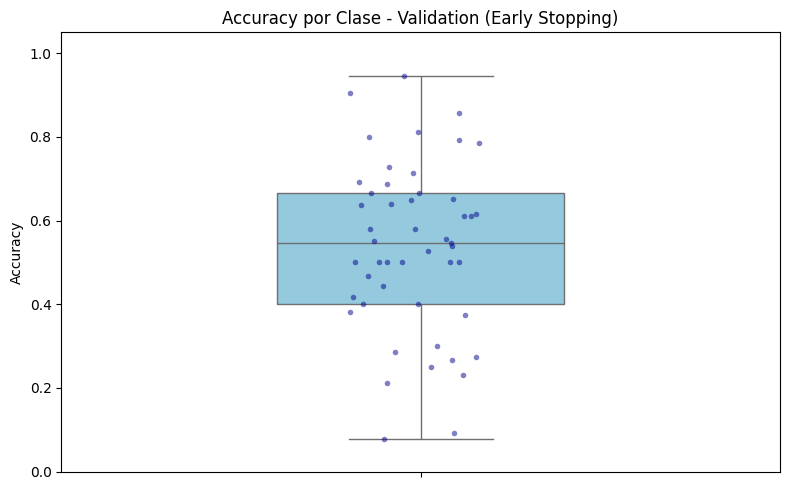

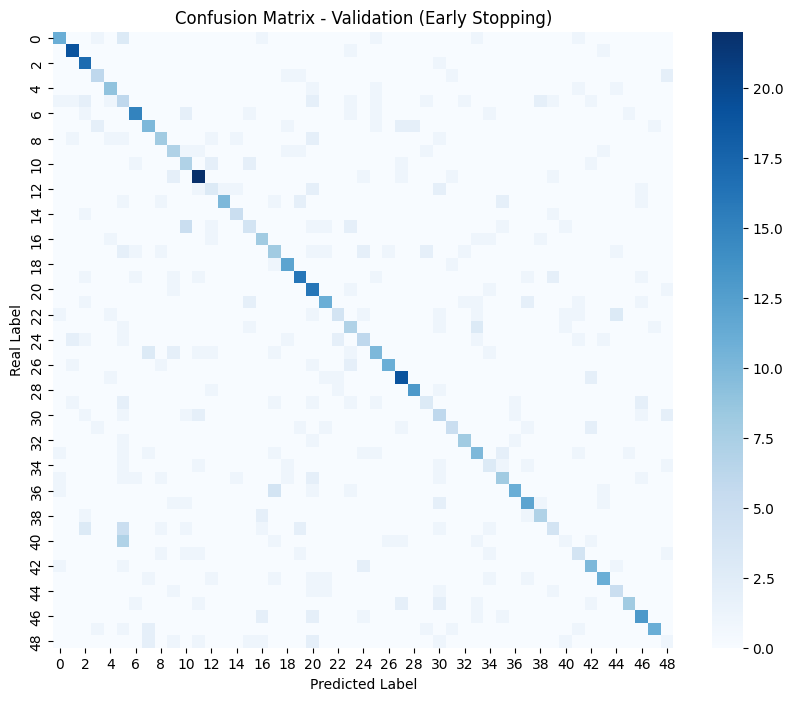

In [102]:
M_es = MLP(n_layers=3, nodes_per_layer=[784, 128, 64, 49], random_seed=RANDOM_SEED)

print("Entrenando con EARLY STOPPING...")
start_time = time.time()
train_loss_es, val_loss_es = M_es.fit(
    X_train_full, y_train_full,
    eta_0=0.1, epochs=300,
    X_val=X_val_full, y_val=y_val_full,
    early_stopping=True, patience=15, min_delta=0.001
)
end_time = time.time()
time_es = end_time - start_time
print(f"Tiempo de entrenamiento: {time_es:.2f} segundos.")

plt.figure(figsize=(10, 6))
plt.plot(train_loss_es, label='Train')
plt.plot(val_loss_es, label='Validation')
plt.title('Evolución del Costo (Cross-Entropy) - Early Stopping')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Evaluar en Train
cm_train_es, accs_train_es = evaluate_model(
    model=M_es,
    X=X_train_full,
    y_one_hot=y_train_full,
    y_labels=y_train,
    num_classes=num_classes,
    name_set="Train (Early Stopping)"
)
plot_confusion_matrix(cm_train_es, title="Confusion Matrix - Train (Early Stopping)")

# Evaluar en Validation
cm_val_es, accs_val_es = evaluate_model(
    model=M_es,
    X=X_val_full,
    y_one_hot=y_val_full,
    y_labels=y_val,
    num_classes=num_classes,
    name_set="Validation (Early Stopping)"
)
plot_confusion_matrix(cm_val_es, title="Confusion Matrix - Validation (Early Stopping)")

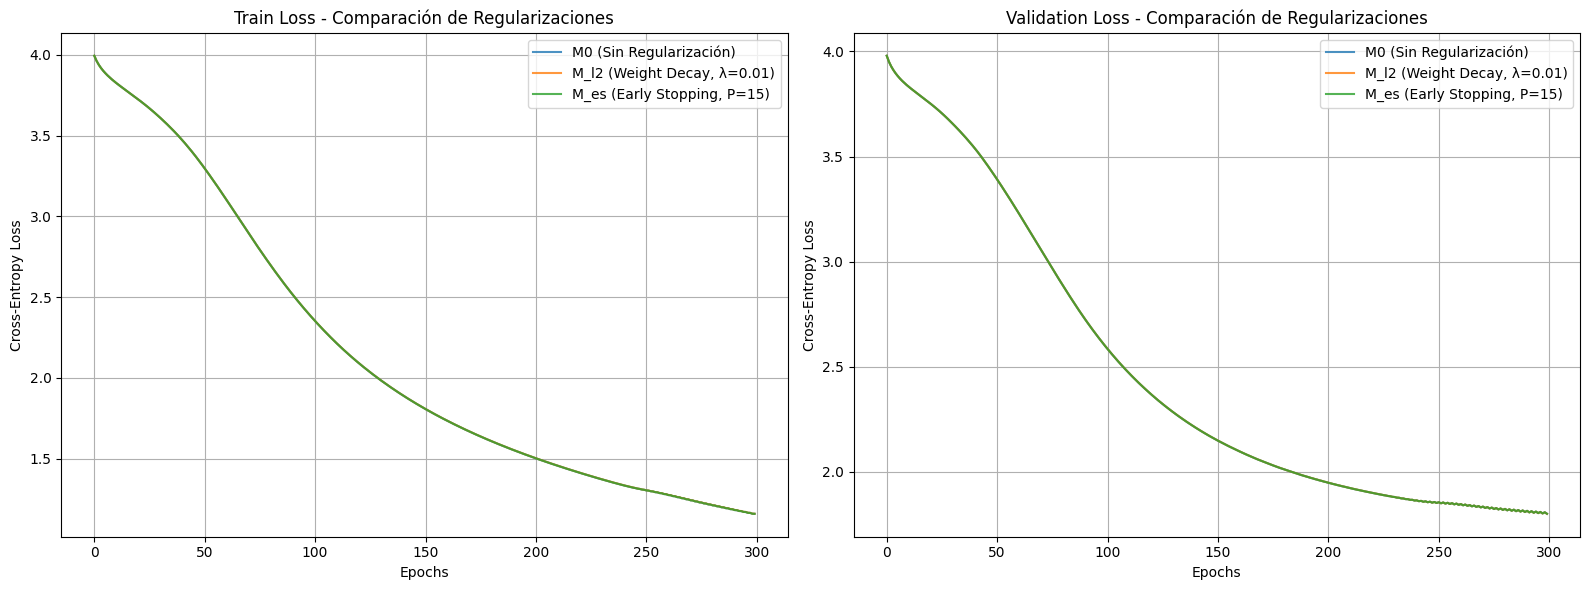


RESUMEN COMPARATIVO DE TÉCNICAS DE REGULARIZACIÓN (Batch GD, η=0.1)
Método                              | Tiempo (s) | Train Acc (%) | Val Acc (%) |   Val Loss
-------------------------------------------------------------------------------------------
M0 (Sin Regularización)             |      16.84 |        72.16% |      55.12% |     1.8007
Weight Decay (L2, λ=0.01)           |      17.25 |        72.16% |      55.12% |     1.8004
Early Stopping (Patience=15)        |       9.46 |        72.16% |      55.12% |     1.8007
-------------------------------------------------------------------------------------------


In [106]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Train Loss ---
axes[0].plot(train_loss_M0, label='M0 (Sin Regularización)', alpha=0.8)
axes[0].plot(train_loss_l2, label='M_l2 (Weight Decay, λ=0.01)', alpha=0.8)
axes[0].plot(train_loss_es, label='M_es (Early Stopping, P=15)', alpha=0.8)
axes[0].set_title('Train Loss - Comparación de Regularizaciones')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend()
axes[0].grid(True)

# --- Validation Loss ---
axes[1].plot(val_loss_M0, label='M0 (Sin Regularización)', alpha=0.8)
axes[1].plot(val_loss_l2, label='M_l2 (Weight Decay, λ=0.01)', alpha=0.8)
axes[1].plot(val_loss_es, label='M_es (Early Stopping, P=15)', alpha=0.8)
axes[1].set_title('Validation Loss - Comparación de Regularizaciones')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Cross-Entropy Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Calcular métricas globales para la tabla
y_pred_M0_train = predict_classes(M0, X_train_full)
y_pred_M0_val = predict_classes(M0, X_val_full)
acc_M0_train = np.mean(y_pred_M0_train == y_train) * 100
acc_M0_val = np.mean(y_pred_M0_val == y_val) * 100

y_pred_l2_train = predict_classes(M_l2, X_train_full)
y_pred_l2_val = predict_classes(M_l2, X_val_full)
acc_l2_train = np.mean(y_pred_l2_train == y_train) * 100
acc_l2_val = np.mean(y_pred_l2_val == y_val) * 100

y_pred_es_train = predict_classes(M_es, X_train_full)
y_pred_es_val = predict_classes(M_es, X_val_full)
acc_es_train = np.mean(y_pred_es_train == y_train) * 100
acc_es_val = np.mean(y_pred_es_val == y_val) * 100

print("\n" + "="*95)
print("RESUMEN COMPARATIVO DE TÉCNICAS DE REGULARIZACIÓN (Batch GD, η=0.1)")
print("="*95)

header = f"{'Método':<35} | {'Tiempo (s)':>10} | {'Train Acc (%)':>13} | {'Val Acc (%)':>11} | {'Val Loss':>10}"
sep = "-" * len(header)
print(header)
print(sep)

print(f"{'M0 (Sin Regularización)':<35} | {training_time_M0:>10.2f} | {acc_M0_train:>12.2f}% | {acc_M0_val:>10.2f}% | {val_loss_M0[-1]:>10.4f}")
print(f"{'Weight Decay (L2, λ=0.01)':<35} | {time_l2:>10.2f} | {acc_l2_train:>12.2f}% | {acc_l2_val:>10.2f}% | {val_loss_l2[-1]:>10.4f}")
print(f"{'Early Stopping (Patience=15)':<35} | {time_es:>10.2f} | {acc_es_train:>12.2f}% | {acc_es_val:>10.2f}% | {val_loss_es[-1]:>10.4f}")
print(sep)

Al evaluar la aplicación aislada de técnicas de regularización (Weight Decay $L_2$ con $\lambda=0.01$ y Early Stopping con una paciencia de 15 épocas) sobre el modelo base entrenado mediante Batch Gradient Descent ($\eta=0.1$), no se observaron variaciones significativas en la métrica de accuracy ni en la función de pérdida. Como se evidencia en la tabla comparativa, las tres configuraciones obtuvieron un $\sim$ 72.1% en entrenamiento y $\sim$ 55.1% en validación. Este fenómeno es un indicador directo del estado de underfitting de M0. Dado que el optimizador Batch GD avanza de forma ineficiente, el modelo nunca alcanza un estado de memorización (overfitting). En consecuencia, la curva de validation desciende de forma monótona sin presentar el característico rebote en forma de "U", lo que impide que la condición de Early Stopping se cumpla. Del mismo modo, la penalización $L_2$ resulta ineficaz, ya que los pesos de la red aún no han adoptado magnitudes elevadas propias del sobreajuste. Esto demuestra que las estrategias de regularización son redundantes si el modelo carece de la dinámica de convergencia necesaria para overfittear inicialmente los datos de train.

Debido a esto se va a probar aplicar las tecnicas de regularizacion para el modelo que utlizaba ADAM (ya que este sufria de un overfitting severo):

In [ ]:
print("\nEntrenando M_adam_l2 (ADAM + Weight Decay L2)...")
M_adam_l2 = MLP(n_layers=3, nodes_per_layer=[784, 128, 64, 49], random_seed=RANDOM_SEED)

start_time = time.time()
train_loss_l2, val_loss_l2 = M_adam_l2.fit(
    X_train_full, y_train_full,
    eta_0=0.001, epochs=300,
    X_val=X_val_full, y_val=y_val_full,
    optimizer="adam", lambda_l2=1
)
time_l2 = time.time() - start_time
print(f"Finalizado en {time_l2:.2f} segundos.")


Entrenando M_adam_l2 (ADAM + Weight Decay L2)...
Finalizado en 9.32 segundos.


In [ ]:
print("\nEntrenando M_adam_es (ADAM + Early Stopping)...")
M_adam_es = MLP(n_layers=3, nodes_per_layer=[784, 128, 64, 49], random_seed=RANDOM_SEED)

start_time = time.time()
train_loss_es, val_loss_es = M_adam_es.fit(
    X_train_full, y_train_full,
    eta_0=0.001, epochs=300,
    X_val=X_val_full, y_val=y_val_full,
    optimizer="adam",
    early_stopping=True, patience=15, min_delta=0.001 
)
time_es = time.time() - start_time
print(f"Finalizado en {time_es:.2f} segundos.")


Entrenando M_adam_es (Mini-batch ADAM + Early Stopping)...
Early Stopping en epoch 100!
Finalizado en 2.84 segundos.


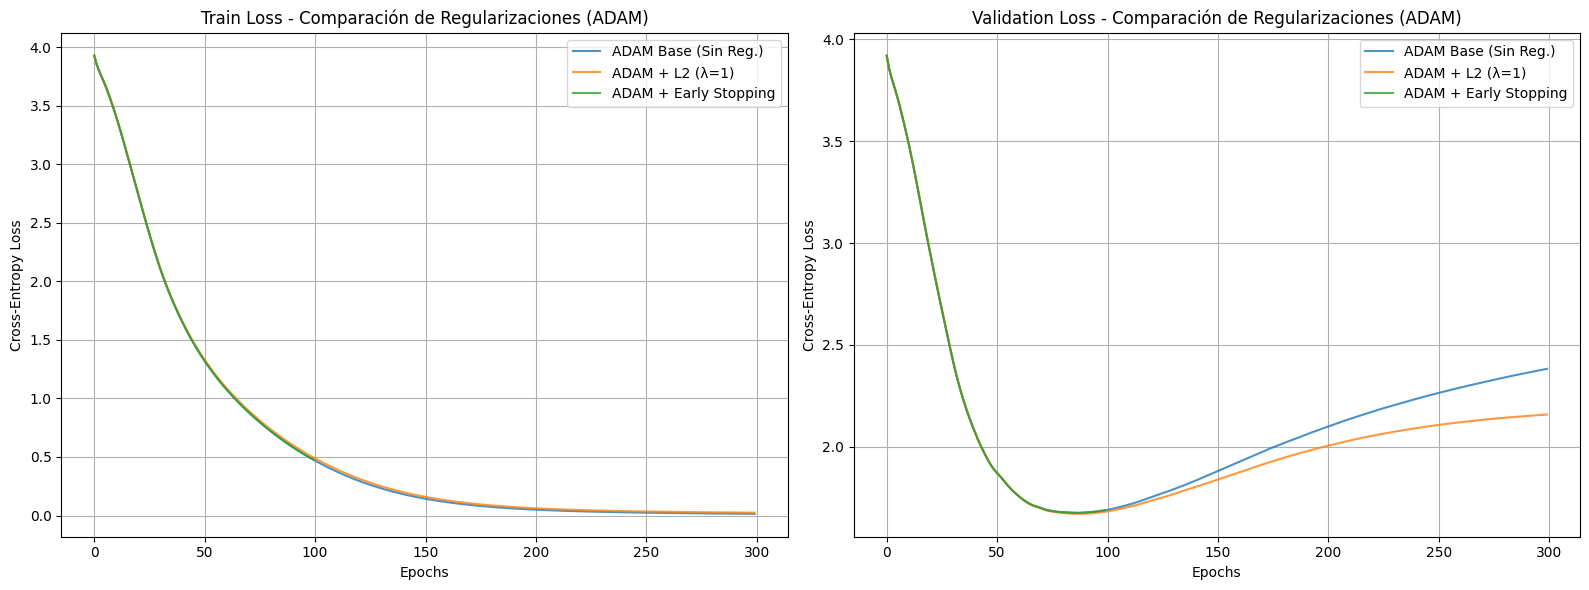


RESUMEN COMPARATIVO DE TÉCNICAS DE REGULARIZACIÓN (ADAM)
Método                              | Tiempo (s) | Train Acc (%) | Val Acc (%) |   Val Loss
-------------------------------------------------------------------------------------------
ADAM Base (Sin Reg.)                |       8.31 |       100.00% |      60.75% |     2.3829
ADAM + L2 (Weight Decay, λ=1)       |       9.32 |       100.00% |      61.12% |     2.1586
ADAM + Early Stopping               |       2.84 |        86.38% |      59.62% |     1.6892
-------------------------------------------------------------------------------------------


In [137]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Train Loss ---
axes[0].plot(train_loss_adam, label='ADAM Base (Sin Reg.)', alpha=0.8)
axes[0].plot(train_loss_l2, label='ADAM + L2 (λ=1)', alpha=0.8)
axes[0].plot(train_loss_es, label='ADAM + Early Stopping', alpha=0.8)
axes[0].set_title('Train Loss - Comparación de Regularizaciones (ADAM)')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend()
axes[0].grid(True)

# --- Validation Loss ---
axes[1].plot(val_loss_adam, label='ADAM Base (Sin Reg.)', alpha=0.8)
axes[1].plot(val_loss_l2, label='ADAM + L2 (λ=1)', alpha=0.8)
axes[1].plot(val_loss_es, label='ADAM + Early Stopping', alpha=0.8)
axes[1].set_title('Validation Loss - Comparación de Regularizaciones (ADAM)')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Cross-Entropy Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Calcular métricas globales
y_pred_base_train = predict_classes(M_adam, X_train_full)
y_pred_base_val = predict_classes(M_adam, X_val_full)
acc_base_train = np.mean(y_pred_base_train == y_train) * 100
acc_base_val = np.mean(y_pred_base_val == y_val) * 100

y_pred_l2_train = predict_classes(M_adam_l2, X_train_full)
y_pred_l2_val = predict_classes(M_adam_l2, X_val_full)
acc_l2_train = np.mean(y_pred_l2_train == y_train) * 100
acc_l2_val = np.mean(y_pred_l2_val == y_val) * 100

y_pred_es_train = predict_classes(M_adam_es, X_train_full)
y_pred_es_val = predict_classes(M_adam_es, X_val_full)
acc_es_train = np.mean(y_pred_es_train == y_train) * 100
acc_es_val = np.mean(y_pred_es_val == y_val) * 100

print("\n" + "="*95)
print("RESUMEN COMPARATIVO DE TÉCNICAS DE REGULARIZACIÓN (ADAM)")
print("="*95)

header = f"{'Método':<35} | {'Tiempo (s)':>10} | {'Train Acc (%)':>13} | {'Val Acc (%)':>11} | {'Val Loss':>10}"
sep = "-" * len(header)
print(header)
print(sep)

print(f"{'ADAM Base (Sin Reg.)':<35} | {time_adam:>10.2f} | {acc_base_train:>12.2f}% | {acc_base_val:>10.2f}% | {val_loss_adam[-1]:>10.4f}")
print(f"{'ADAM + L2 (Weight Decay, λ=1)':<35} | {time_l2:>10.2f} | {acc_l2_train:>12.2f}% | {acc_l2_val:>10.2f}% | {val_loss_l2[-1]:>10.4f}")
print(f"{'ADAM + Early Stopping':<35} | {time_es:>10.2f} | {acc_es_train:>12.2f}% | {acc_es_val:>10.2f}% | {val_loss_es[-1]:>10.4f}")
print(sep)

La evaluación comparativa de regularizadores sobre el optimizador ADAM revela dinámicas divergentes frente al fenómeno de overfitting. Al implementar Weight Decay ($L_2$) con una penalización severa ($\lambda=1$), el modelo mantuvo un 100% de precisión en entrenamiento y apenas logró una reducción en la pérdida de validación (de 2.3829 a 2.1586), invirtiendo mayor tiempo de cómputo (9.32s). Esta leve mejora sugiere que, aunque el regularizador contuvo marginalmente el crecimiento desmedido de los pesos, la inercia adaptativa del optimizador ADAM logró sortear la penalización para seguir memorizando el ruido local del conjunto de entrenamiento. Por el contrario, la técnica de Early Stopping (configurada con paciencia de 15 épocas) probó ser un mecanismo de contención superior y altamente eficiente. Al interrumpir el ciclo iterativo de manera proactiva, no solo redujo drásticamente el tiempo de ejecución a 2.84 segundos, sino que obtuvo la pérdida de validación más baja del experimento (1.6892), forzando al modelo a retener una abstracción más general (86.38% de precisión en entrenamiento) antes de que la fase de memorización pudiera degradar sus capacidades predictivas.